Nome: Ícaro Oliveira de Andrade Fernandes Velásquez Solís

Matrícula:20210026008

# 1.Imports

In [1]:
pip install ucimlrepo

Note: you may need to restart the kernel to use updated packages.


In [2]:
#import do restante das bibliotecas necessárias
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
from ucimlrepo import fetch_ucirepo

# fetch dataset
diabetes_130_us_hospitals_for_years_1999_2008 = fetch_ucirepo(id=296)

# data (as pandas dataframes)
X = diabetes_130_us_hospitals_for_years_1999_2008.data.features
y = diabetes_130_us_hospitals_for_years_1999_2008.data.targets

# metadata
print(diabetes_130_us_hospitals_for_years_1999_2008.metadata)

# variable information
print(diabetes_130_us_hospitals_for_years_1999_2008.variables)


/home/icaro/Documentos/Prova02_ML/.venv/lib/python3.12/site-packages/ucimlrepo/fetch.py:97: DtypeWarning: Columns (0: payer_code) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(data_url)


{'uci_id': 296, 'name': 'Diabetes 130-US Hospitals for Years 1999-2008', 'repository_url': 'https://archive.ics.uci.edu/dataset/296/diabetes+130-us+hospitals+for+years+1999-2008', 'data_url': 'https://archive.ics.uci.edu/static/public/296/data.csv', 'abstract': 'The dataset represents ten years (1999-2008) of clinical care at 130 US hospitals and integrated delivery networks. Each row concerns hospital records of patients diagnosed with diabetes, who underwent laboratory, medications, and stayed up to 14 days. The goal is to determine the early readmission of the patient within 30 days of discharge.\nThe problem is important for the following reasons. Despite high-quality evidence showing improved clinical outcomes for diabetic patients who receive various preventive and therapeutic interventions, many patients do not receive them. This can be partially attributed to arbitrary diabetes management in hospital environments, which fail to attend to glycemic control. Failure to provide pro

# 2.  Análise exploratória dos dados (EDA)

## 2.1 Análise dos tipos e valores faltantes

In [4]:
X.describe()

,admission_type_id,discharge_disposition_id,admission_source_id,time_in_hospital,num_lab_procedures,num_procedures,num_medications,number_outpatient,number_emergency,number_inpatient,number_diagnoses
count,101766.000000,101766.000000,101766.000000,101766.000000,101766.000000,101766.000000,101766.000000,101766.000000,101766.000000,101766.000000,101766.000000
mean,2.024006,3.715642,5.754437,4.395987,43.095641,1.339730,16.021844,0.369357,0.197836,0.635566,7.422607
std,1.445403,5.280166,4.064081,2.985108,19.674362,1.705807,8.127566,1.267265,0.930472,1.262863,1.933600
min,1.000000,1.000000,1.000000,1.000000,1.000000,0.000000,1.000000,0.000000,0.000000,0.000000,1.000000
25%,1.000000,1.000000,1.000000,2.000000,31.000000,0.000000,10.000000,0.000000,0.000000,0.000000,6.000000
50%,1.000000,1.000000,7.000000,4.000000,44.000000,1.000000,15.000000,0.000000,0.000000,0.000000,8.000000
75%,3.000000,4.000000,7.000000,6.000000,57.000000,2.000000,20.000000,0.000000,0.000000,1.000000,9.000000
max,8.000000,28.000000,25.000000,14.000000,132.000000,6.000000,81.000000,42.000000,76.000000,21.000000,16.000000


In [5]:
#entendimento da variável target
print(y.columns)
print(y.shape)

Index(['readmitted'], dtype='str')
(101766, 1)


In [6]:
#entendimento da variável target
print(y['readmitted'].unique())
print(y['readmitted'].value_counts())
print(y['readmitted'])

<StringArray>
['NO', '>30', '<30']
Length: 3, dtype: str
readmitted
NO     54864
>30    35545
<30    11357
Name: count, dtype: int64
0          NO
1         >30
2          NO
3          NO
4          NO
         ... 
101761    >30
101762     NO
101763     NO
101764     NO
101765     NO
Name: readmitted, Length: 101766, dtype: str


Então o que temos é uma variável target categórica que tem dados sobre pacientes que foram reinternados em três tipos :


*   'NO' = Não houve reinternação
*   '>30' = Reinternado após 30 dias
*   '<30' = Reinternado antes de 30 dias
Ela é objeto pandas string, e tem 101766 linhas. A somatória dos valores únicos batem com as linhas printadas anteriormente da variável, então não há valores faltantes, exatamente como dito pelo dataset




In [7]:
print(X.info())
print(X.shape)

<class 'pandas.DataFrame'>
RangeIndex: 101766 entries, 0 to 101765
Data columns (total 47 columns):
 #   Column                    Non-Null Count   Dtype
---  ------                    --------------   -----
 0   race                      99493 non-null   str  
 1   gender                    101766 non-null  str  
 2   age                       101766 non-null  str  
 3   weight                    3197 non-null    str  
 4   admission_type_id         101766 non-null  int64
 5   discharge_disposition_id  101766 non-null  int64
 6   admission_source_id       101766 non-null  int64
 7   time_in_hospital          101766 non-null  int64
 8   payer_code                61510 non-null   str  
 9   medical_specialty         51817 non-null   str  
 10  num_lab_procedures        101766 non-null  int64
 11  num_procedures            101766 non-null  int64
 12  num_medications           101766 non-null  int64
 13  number_outpatient         101766 non-null  int64
 14  number_emergency          10176

In [8]:
nulos_df = pd.DataFrame({
    'contagem':X.isnull().sum(),
    'percentual':X.isnull().sum()/len(X)*100
})
nulos_df[nulos_df['contagem'] > 0]


,contagem,percentual
race,2273,2.233555
weight,98569,96.858479
payer_code,40256,39.557416
medical_specialty,49949,49.082208
diag_1,21,0.020636
diag_2,358,0.351787
diag_3,1423,1.398306
max_glu_serum,96420,94.746772
A1Cresult,84748,83.277322


Temos variáveis de tipos diferentes, inteiros(11) e strings(36).Temos também algumas variáveis com muitos valores faltantes, por exemplo:


1. **weight** = 96% de valores faltantes
2. **max_glu_serum** = 94% de valores faltantes
3. **A1Cresult** = 83% de valores faltantes

Temos também outras duas variáveis com umm número médio de valores faltantes:


1.   **payer_code** = 39%
2.   **medical_specialty** = 49%

Os demais valores tem porcentagens baixas(<3%) de dados faltantes






## 2.2 Análise de Duplicatas

In [9]:
# Verificação de duplicatas
print(f"Total de registros: {len(X):,}")
print(f"Duplicatas em X (apenas features): {X.duplicated().sum()}")

df_full = X.copy()
df_full['readmitted'] = y['readmitted'].values
dup = df_full.duplicated().sum()
print(f"Duplicatas no dataset completo (X + y): {dup}")
print(f"Percentual: {dup / len(df_full) * 100:.4f}%")

Total de registros: 101,766
Duplicatas em X (apenas features): 0
Duplicatas no dataset completo (X + y): 0
Percentual: 0.0000%


Não foram encontradas duplicatas exatas. Isso é esperado em dados hospitalares: cada linha representa uma internação única com combinações distintas de procedimentos, diagnósticos e datas — mesmo que o mesmo paciente apareça várias vezes, cada internação difere em seus detalhes clínicos.

## 2.3 Distribuição das Classes

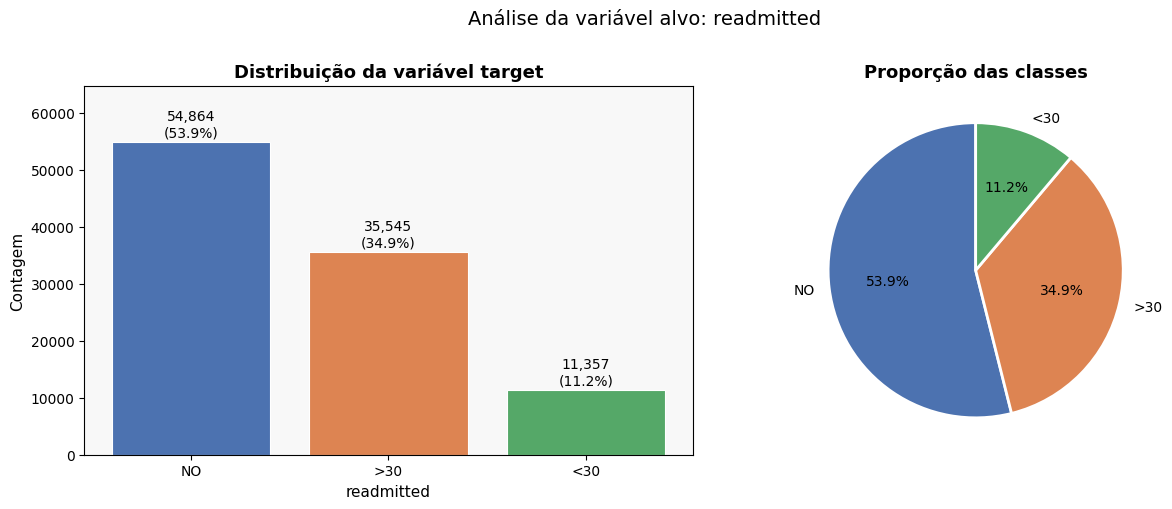

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
counts = y['readmitted'].value_counts()
cores = ['#4C72B0', '#DD8452', '#55A868']

bars = axes[0].bar(counts.index, counts.values, color=cores, edgecolor='white', linewidth=0.8)
axes[0].set_title('Distribuição da variável target', fontsize=13, fontweight='bold')
axes[0].set_xlabel('readmitted', fontsize=11)
axes[0].set_ylabel('Contagem', fontsize=11)
for bar, (label, count) in zip(bars, counts.items()):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 500,
                 f'{count:,}\n({count/len(y)*100:.1f}%)', ha='center', va='bottom', fontsize=10)
axes[0].set_ylim(0, counts.max() * 1.18)
axes[0].set_facecolor('#f8f8f8')

axes[1].pie(counts.values, labels=counts.index, autopct='%1.1f%%', colors=cores,
            startangle=90, wedgeprops={'edgecolor': 'white', 'linewidth': 2})
axes[1].set_title('Proporção das classes', fontsize=13, fontweight='bold')

plt.suptitle('Análise da variável alvo: readmitted', fontsize=14, y=1.01)
plt.tight_layout()
plt.show()

O dataset apresenta **desbalanceamento de classes**:
- **NO** (sem reinternação): 53,9% — classe majoritária
- **>30** (reinternado após 30 dias): 34,9%
- **<30** (reinternado antes de 30 dias): 11,2% — classe minoritária

A proporção de ~5:1 entre a classe mais frequente e a menos frequente exige atenção: modelos treinados sem ajuste tendem a ignorar a classe `<30`. Técnicas como `class_weight='balanced'` ou SMOTE serão necessárias nas etapas de modelagem.

# 3. Pré-processamento

## 3.1 Tratamento de Valores Ausentes

In [11]:
# DataFrame de trabalho
df = X.copy()
df['readmitted'] = y['readmitted'].values
print(f"Shape inicial: {df.shape}")

# Estratégia 1: remover colunas com >40% de nulos
cols_alto_nulo = ['weight', 'max_glu_serum', 'A1Cresult', 'payer_code']
df.drop(columns=cols_alto_nulo, inplace=True)
print(f"\nRemoção por excesso de nulos (>40%): {cols_alto_nulo}")

# Estratégia 2: medical_specialty → categoria 'Unknown'
df['medical_specialty'] = df['medical_specialty'].fillna('Unknown')

# Estratégia 3: race → moda
moda_race = df['race'].mode()[0]
df['race'] = df['race'].fillna(moda_race)
print(f"race preenchida com moda: '{moda_race}'")

# Estratégia 4: remover linhas com nulos em diag_1/2/3 (<2%)
antes = len(df)
df.dropna(subset=['diag_1', 'diag_2', 'diag_3'], inplace=True)
print(f"Linhas removidas (nulos em diag_*): {antes - len(df)} ({(antes - len(df))/antes*100:.2f}%)")

print(f"\nNulos restantes: {df.isnull().sum().sum()}")
print(f"Shape final: {df.shape}")

Shape inicial: (101766, 48)

Remoção por excesso de nulos (>40%): ['weight', 'max_glu_serum', 'A1Cresult', 'payer_code']
race preenchida com moda: 'Caucasian'
Linhas removidas (nulos em diag_*): 1522 (1.50%)

Nulos restantes: 0
Shape final: (100244, 44)


**Justificativas das estratégias adotadas:**

| Coluna | Ausentes | Estratégia | Justificativa |
|--------|----------|------------|---------------|
| `weight` | 96,9% | Remoção da coluna | Mais de 96% dos dados estão ausentes — qualquer imputação distorceria completamente o dado real |
| `max_glu_serum` | 94,7% | Remoção da coluna | Alta ausência + o teste de glicemia sérica não era rotineiro no período (1999–2008) |
| `A1Cresult` | 83,3% | Remoção da coluna | Alta ausência e a informação já é parcialmente representada por outras variáveis clínicas |
| `payer_code` | 39,6% | Remoção da coluna | Alto percentual e irrelevante clinicamente para prever reinternação |
| `medical_specialty` | 49,1% | Categoria 'Unknown' | A ausência pode ser informativa (paciente sem especialidade registrada); criar categoria evita perda de ~49 mil linhas |
| `race` | 2,2% | Moda | Percentual baixo; substituição pela categoria mais frequente tem impacto mínimo |
| `diag_1/2/3` | < 2% | Remoção de linhas | Diagnósticos são variáveis centrais; imputação seria inadequada, e a perda de linhas é mínima |

## 3.2 Remoção de Colunas Inadequadas

In [12]:
# 1. Colunas com valor único (variância zero = sem poder preditivo)
cols_valor_unico = [col for col in df.columns
                    if col != 'readmitted' and df[col].nunique() == 1]
print(f"Colunas com valor único: {cols_valor_unico}")
df.drop(columns=cols_valor_unico, inplace=True)

# 2. Remover registros com gender inválido
print(f"\nValores em gender: {df['gender'].value_counts().to_dict()}")
df = df[~df['gender'].isin(['Unknown/Invalid'])]
print(f"Registros gender inválido removidos")

# 3. Remover registros de óbito/hospice
# discharge_disposition_id 11,13,14 = óbito; 19,20,21 = hospice
# Pacientes que faleceram não podem ser reinternados — mantê-los como 'NO' enviesaria o modelo
obitos = [11, 13, 14, 19, 20, 21]
antes = len(df)
df = df[~df['discharge_disposition_id'].isin(obitos)]
print(f"Registros de óbito/hospice removidos: {antes - len(df)}")

print(f"\nShape final: {df.shape}")

Colunas com valor único: ['examide', 'citoglipton']

Valores em gender: {'Female': 53922, 'Male': 46319, 'Unknown/Invalid': 3}
Registros gender inválido removidos
Registros de óbito/hospice removidos: 2419

Shape final: (97822, 42)


**Justificativas:**

- **`examide`, `citoglipton`** (e similares com valor único): Possuem o mesmo valor em todas as linhas — variância zero, portanto sem qualquer poder preditivo. Incluí-los apenas aumentaria o ruído.

- **`gender = 'Unknown/Invalid'`**: Representa erro de entrada de dados. A fração é mínima e esses registros não têm valor informativo.

- **Óbitos e hospice** (`discharge_disposition_id` ∈ {11, 13, 14, 19, 20, 21}): Pacientes que foram a óbito ou transferidos para cuidados paliativos **não podem ser clinicamente reinternados**. Mantê-los com `readmitted = 'NO'` é uma verdade trivial e introduziria viés — o modelo aprenderia que "morrer leva a não reinternação", o que não é útil.

- **`encounter_id` e `patient_nbr`**: São identificadores únicos que o ucimlrepo já exclui das features automaticamente. Se estivessem presentes, deveriam ser removidos por serem chaves sem informação preditiva.

## 3.3 Codificação de Atributos Categóricos

O dataset possui dois tipos de variáveis categóricas:
1. **Ordinais/Binárias** — têm ordem natural ou apenas dois estados → **Label Encoding**
2. **Nominais** — sem hierarquia entre categorias → **One-Hot Encoding**

### 3.3.1 Estratégia 1 — Label Encoding (variáveis ordinais e binárias)

In [13]:
df_encoded = df.copy()

# age: faixas etárias com ordem clara
age_map = {'[0-10)': 0, '[10-20)': 1, '[20-30)': 2, '[30-40)': 3, '[40-50)': 4,
           '[50-60)': 5, '[60-70)': 6, '[70-80)': 7, '[80-90)': 8, '[90-100)': 9}
df_encoded['age'] = df_encoded['age'].map(age_map)
print("age → ordinal [0–9]")

# gender: binária
df_encoded['gender'] = df_encoded['gender'].map({'Male': 0, 'Female': 1})
print("gender → Male=0, Female=1")

# Detectar automaticamente colunas de medicamentos (No/Steady/Down/Up)
# pandas 3.x usa StringDtype, então usamos pd.api.types.is_string_dtype
med_map = {'No': 0, 'Steady': 1, 'Down': 2, 'Up': 3}
med_cols = [col for col in df_encoded.columns
            if col not in ['readmitted', 'age', 'gender', 'change', 'diabetesMed']
            and pd.api.types.is_string_dtype(df_encoded[col])
            and set(df_encoded[col].dropna().unique()).issubset(set(med_map.keys()))]
for col in med_cols:
    df_encoded[col] = df_encoded[col].map(med_map)
print(f"Medicamentos detectados ({len(med_cols)} colunas) → No=0, Steady=1, Down=2, Up=3")
print(f"  {med_cols}")

# Binárias restantes
df_encoded['change'] = df_encoded['change'].map({'No': 0, 'Ch': 1})
df_encoded['diabetesMed'] = df_encoded['diabetesMed'].map({'No': 0, 'Yes': 1})
print("change → No=0, Ch=1  |  diabetesMed → No=0, Yes=1")

str_restantes = [c for c in df_encoded.columns if c != 'readmitted'
                 and pd.api.types.is_string_dtype(df_encoded[c])]
print(f"\nShape após Label Encoding: {df_encoded.shape}")
print(f"Colunas ainda string (a tratar com OHE): {str_restantes}")

age → ordinal [0–9]
gender → Male=0, Female=1
Medicamentos detectados (21 colunas) → No=0, Steady=1, Down=2, Up=3
  ['metformin', 'repaglinide', 'nateglinide', 'chlorpropamide', 'glimepiride', 'acetohexamide', 'glipizide', 'glyburide', 'tolbutamide', 'pioglitazone', 'rosiglitazone', 'acarbose', 'miglitol', 'troglitazone', 'tolazamide', 'insulin', 'glyburide-metformin', 'glipizide-metformin', 'glimepiride-pioglitazone', 'metformin-rosiglitazone', 'metformin-pioglitazone']
change → No=0, Ch=1  |  diabetesMed → No=0, Yes=1

Shape após Label Encoding: (97822, 42)
Colunas ainda string (a tratar com OHE): ['race', 'medical_specialty', 'diag_1', 'diag_2', 'diag_3']


**Por que Label Encoding aqui?**

- **`age`**: As faixas etárias têm ordem natural inequívoca — [0-10) é menor que [10-20) etc. O Label Encoding preserva essa relação ordinal, o que é semanticamente correto e mais compacto que OHE.
- **`gender`**: Variável binária. Um único valor 0/1 é equivalente a OHE sem criar coluna extra.
- **Medicamentos** (metformin, insulin, etc.): Os valores representam progressão de uso do medicamento: sem uso (No) → dose estável (Steady) → ajuste (Down/Up). O encoding ordinal é uma simplificação razoável e amplamente adotada na literatura sobre este dataset.
- **`change`, `diabetesMed`**: Puramente binárias, sem ambiguidade.

### 3.3.2 Estratégia 2 — One-Hot Encoding (variáveis nominais)

In [14]:
# Agrupar diag_1/2/3 por sistemas do corpo (CID-9)
def categorizar_icd9(codigo):
    try:
        codigo = str(codigo).strip()
        if codigo.startswith('V') or codigo.startswith('E'):
            return 'Externo'
        num = float(codigo.split('.')[0])
        if 390 <= num <= 459 or num == 785: return 'Circulatório'
        if 460 <= num <= 519 or num == 786: return 'Respiratório'
        if 520 <= num <= 579 or num == 787: return 'Digestivo'
        if num == 250:                       return 'Diabetes'
        if 800 <= num <= 999:                return 'Lesão/Envenenamento'
        if 710 <= num <= 739:                return 'Musculoesquelético'
        if 580 <= num <= 629 or num == 788:  return 'Geniturinário'
        if 140 <= num <= 239:                return 'Neoplasias'
        return 'Outros'
    except:
        return 'Outros'

for col in ['diag_1', 'diag_2', 'diag_3']:
    df_encoded[col + '_cat'] = df_encoded[col].apply(categorizar_icd9)
    df_encoded.drop(columns=[col], inplace=True)

print("diag_1/2/3 → categorias CID-9")
print(f"Distribuição diag_1: {df_encoded['diag_1_cat'].value_counts().to_dict()}")

# Agrupar medical_specialty: manter top 10 + 'Outros'
top_spec = df_encoded['medical_specialty'].value_counts().nlargest(10).index.tolist()
df_encoded['medical_specialty'] = df_encoded['medical_specialty'].apply(
    lambda x: x if x in top_spec else 'Outros'
)
print(f"\nEspecialidades mantidas: {top_spec}")

# One-Hot Encoding
colunas_ohe = ['race', 'medical_specialty', 'diag_1_cat', 'diag_2_cat', 'diag_3_cat']
df_encoded = pd.get_dummies(df_encoded, columns=colunas_ohe, drop_first=False, dtype=int)

print(f"\nShape após One-Hot Encoding: {df_encoded.shape}")
print(f"Colunas object restantes: {list(df_encoded.select_dtypes('object').columns)}")

diag_1/2/3 → categorias CID-9
Distribuição diag_1: {'Circulatório': 29550, 'Outros': 15972, 'Respiratório': 13817, 'Digestivo': 9221, 'Diabetes': 8039, 'Lesão/Envenenamento': 6713, 'Geniturinário': 4960, 'Musculoesquelético': 4836, 'Neoplasias': 3088, 'Externo': 1626}

Especialidades mantidas: ['Unknown', 'InternalMedicine', 'Emergency/Trauma', 'Family/GeneralPractice', 'Cardiology', 'Surgery-General', 'Nephrology', 'Orthopedics', 'Orthopedics-Reconstructive', 'Radiologist']

Shape após One-Hot Encoding: (97822, 83)
Colunas object restantes: ['readmitted']


/tmp/ipykernel_207053/1872467391.py:39: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  print(f"Colunas object restantes: {list(df_encoded.select_dtypes('object').columns)}")


**Por que One-Hot Encoding aqui?**

- **`race`**: Raça não tem ordem — "Caucasiano" não é numericamente maior que "Africano-Americano". Label Encoding criaria uma relação numérica artificial que o modelo interpretaria como hierarquia inexistente. O OHE cria uma coluna binária por categoria, mantendo a neutralidade.

- **`medical_specialty`**: Especialidades médicas são igualmente nominais. Como há muitas especialidades raras, agrupamos as menos frequentes em "Outros" para evitar explosão de esparsidade e reduzir ruído.

- **`diag_1/2/3`**: Os códigos CID-9 brutos têm altíssima cardinalidade (centenas de valores únicos). Agrupá-los nos 9 sistemas orgânicos principais antes do OHE é semanticamente mais rico, reduz a dimensionalidade e evita que o modelo trate "código 250.01" como próximo de "código 250.02" (o que seria incorreto sem contexto médico).

## 3.4 Redimensionamento e Seleção de Atributos

In [15]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.decomposition import PCA
from sklearn.metrics import accuracy_score, f1_score
import warnings
warnings.filterwarnings('ignore')

# Separar features e target
le_target = LabelEncoder()
y_enc = le_target.fit_transform(df_encoded['readmitted'])
X_enc = df_encoded.drop(columns=['readmitted'])

mapeamento = dict(zip(le_target.classes_, le_target.transform(le_target.classes_)))
print(f"Mapeamento do target: {mapeamento}")
print(f"X shape: {X_enc.shape}  |  y shape: {y_enc.shape}")

# Split estratificado
X_train, X_test, y_train, y_test = train_test_split(
    X_enc, y_enc, test_size=0.2, random_state=42, stratify=y_enc
)
print(f"Treino: {X_train.shape[0]:,}  |  Teste: {X_test.shape[0]:,}")

# Escalonamento (necessário para LR e PCA)
scaler = StandardScaler()
X_train_sc = scaler.fit_transform(X_train)
X_test_sc  = scaler.transform(X_test)

Mapeamento do target: {'<30': np.int64(0), '>30': np.int64(1), 'NO': np.int64(2)}
X shape: (97822, 82)  |  y shape: (97822,)
Treino: 78,257  |  Teste: 19,565


### 3.4.1 Linha de Base — Todos os atributos

Utilizamos a **Árvore de Decisão** (mesmo modelo avaliado na Seção 4) com parâmetros fixos
(`max_depth=5`, `min_samples_leaf=20`, `class_weight='balanced'`) para manter consistência
e tornar a comparação diretamente interpretável em relação à seção de modelos supervisionados.

In [16]:
# Árvore de Decisão como modelo de referência
# (mesma família usada na Seção 4; invariante ao escalonamento)
dt_cmp = DecisionTreeClassifier(max_depth=5, min_samples_leaf=20,
                                  class_weight='balanced', random_state=42)
dt_cmp.fit(X_train, y_train)
y_pred_base = dt_cmp.predict(X_test)

acc_base = accuracy_score(y_test, y_pred_base)
f1_base  = f1_score(y_test, y_pred_base, average='weighted')

print(f"=== BASELINE — {X_enc.shape[1]} atributos ===")
print(f"Accuracy:      {acc_base:.4f}")
print(f"F1 (weighted): {f1_base:.4f}")

=== BASELINE — 82 atributos ===
Accuracy:      0.4888
F1 (weighted): 0.4809


### 3.4.2 Seleção por Importância — Random Forest

Treinando Random Forest para calcular importâncias... (pode levar ~1min)


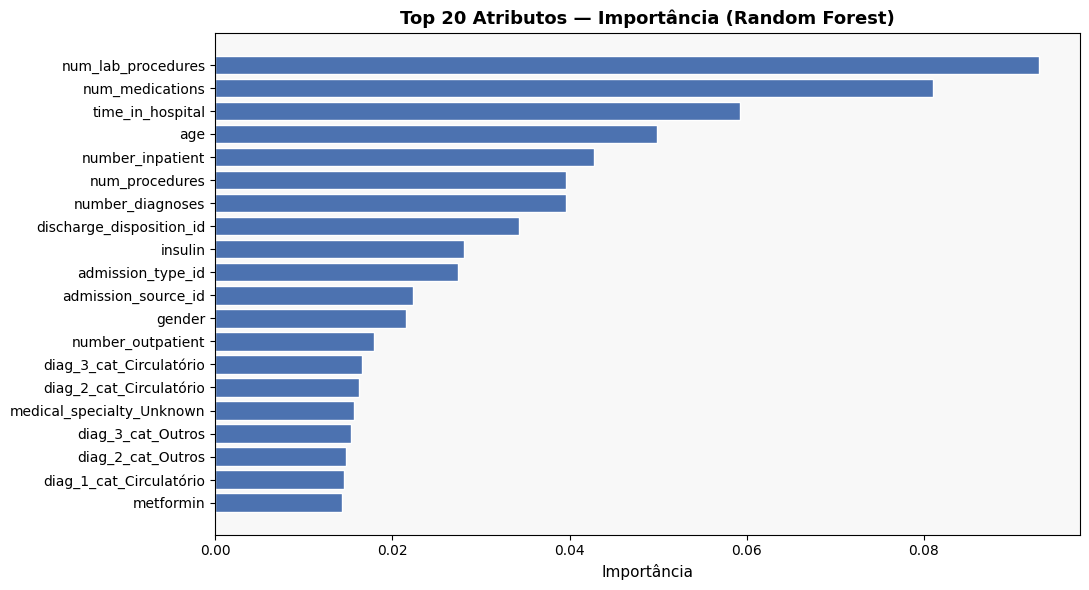


Top 20 features:
['num_lab_procedures', 'num_medications', 'time_in_hospital', 'age', 'number_inpatient', 'num_procedures', 'number_diagnoses', 'discharge_disposition_id', 'insulin', 'admission_type_id', 'admission_source_id', 'gender', 'number_outpatient', 'diag_3_cat_Circulatório', 'diag_2_cat_Circulatório', 'medical_specialty_Unknown', 'diag_3_cat_Outros', 'diag_2_cat_Outros', 'diag_1_cat_Circulatório', 'metformin']


In [17]:
print("Treinando Random Forest para calcular importâncias... (pode levar ~1min)")
rf = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1, class_weight='balanced')
rf.fit(X_train, y_train)

importancias = pd.Series(rf.feature_importances_, index=X_enc.columns).sort_values(ascending=False)

fig, ax = plt.subplots(figsize=(11, 6))
top20 = importancias.head(20)
ax.barh(top20.index[::-1], top20.values[::-1], color='#4C72B0', edgecolor='white')
ax.set_title('Top 20 Atributos — Importância (Random Forest)', fontsize=13, fontweight='bold')
ax.set_xlabel('Importância', fontsize=11)
ax.set_facecolor('#f8f8f8')
plt.tight_layout()
plt.show()

top_features = importancias.head(20).index.tolist()
print(f"\nTop 20 features:\n{top_features}")

In [18]:
# Avaliação com top 20 features (DT — não necessita escalonamento)
dt_sel = DecisionTreeClassifier(max_depth=5, min_samples_leaf=20,
                                  class_weight='balanced', random_state=42)
dt_sel.fit(X_train[top_features], y_train)
y_pred_sel = dt_sel.predict(X_test[top_features])

acc_sel = accuracy_score(y_test, y_pred_sel)
f1_sel  = f1_score(y_test, y_pred_sel, average='weighted')

print(f"=== SELEÇÃO POR IMPORTÂNCIA — 20 atributos ===")
print(f"Accuracy:      {acc_sel:.4f}")
print(f"F1 (weighted): {f1_sel:.4f}")

=== SELEÇÃO POR IMPORTÂNCIA — 20 atributos ===
Accuracy:      0.4904
F1 (weighted): 0.4837


A seleção por importância do Random Forest identifica quais atributos mais reduzem a impureza das
árvores de decisão. Neste dataset, atributos como `number_inpatient` (internações anteriores),
`discharge_disposition_id` e métricas de procedimentos tendem a liderar — o que faz sentido
clínico: histórico de internação é o melhor preditor de reinternação.

Usar apenas as top 20 features (~30% do total) já captura a maior parte da variância preditiva,
indicando que o dataset tem muitas features redundantes (especialmente os medicamentos raramente
prescritos que ficam quase sempre como "No"). A Árvore de Decisão avalia diretamente a relevância
das features sem necessidade de escalonamento, tornando a comparação particularmente limpa.

### 3.4.3 PCA — Análise de Componentes Principais

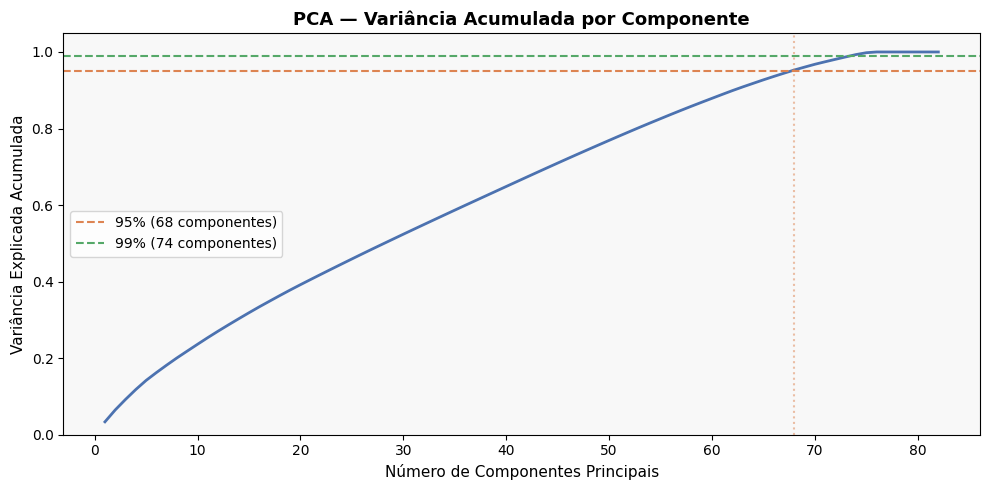

Atributos originais: 82
Componentes para 95% de variância: 68
Componentes para 99% de variância: 74


In [19]:
pca_full = PCA(random_state=42)
pca_full.fit(X_train_sc)

var_acumulada = np.cumsum(pca_full.explained_variance_ratio_)
n_95 = int(np.argmax(var_acumulada >= 0.95)) + 1
n_99 = int(np.argmax(var_acumulada >= 0.99)) + 1

fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(range(1, len(var_acumulada) + 1), var_acumulada, color='#4C72B0', linewidth=2)
ax.axhline(0.95, color='#DD8452', linestyle='--', label=f'95% ({n_95} componentes)')
ax.axhline(0.99, color='#55A868', linestyle='--', label=f'99% ({n_99} componentes)')
ax.axvline(n_95, color='#DD8452', linestyle=':', alpha=0.5)
ax.set_xlabel('Número de Componentes Principais', fontsize=11)
ax.set_ylabel('Variância Explicada Acumulada', fontsize=11)
ax.set_title('PCA — Variância Acumulada por Componente', fontsize=13, fontweight='bold')
ax.legend(fontsize=10)
ax.set_facecolor('#f8f8f8')
ax.set_ylim(0, 1.05)
plt.tight_layout()
plt.show()

print(f"Atributos originais: {X_train_sc.shape[1]}")
print(f"Componentes para 95% de variância: {n_95}")
print(f"Componentes para 99% de variância: {n_99}")

In [20]:
# Aplicar PCA com 95% de variância explicada (sobre dados escalonados)
pca_95 = PCA(n_components=0.95, random_state=42)
X_train_pca = pca_95.fit_transform(X_train_sc)
X_test_pca  = pca_95.transform(X_test_sc)

print(f"Shape treino com PCA (95%): {X_train_pca.shape}")

# DT aplicado sobre as componentes principais
dt_pca = DecisionTreeClassifier(max_depth=5, min_samples_leaf=20,
                                  class_weight='balanced', random_state=42)
dt_pca.fit(X_train_pca, y_train)
y_pred_pca = dt_pca.predict(X_test_pca)

acc_pca = accuracy_score(y_test, y_pred_pca)
f1_pca  = f1_score(y_test, y_pred_pca, average='weighted')

print(f"\n=== PCA 95% — {pca_95.n_components_} componentes ===")
print(f"Accuracy:      {acc_pca:.4f}")
print(f"F1 (weighted): {f1_pca:.4f}")

Shape treino com PCA (95%): (78257, 68)

=== PCA 95% — 68 componentes ===
Accuracy:      0.4236
F1 (weighted): 0.4423


### 3.4.4 Comparação de Desempenho

               Configuração  Accuracy  F1 (weighted)  Nº Atributos
    Todos os atributos (82)  0.488781       0.480858            82
Top 20 por importância (20)  0.490365       0.483664            20
   PCA 95% (68 componentes)  0.423562       0.442291            68


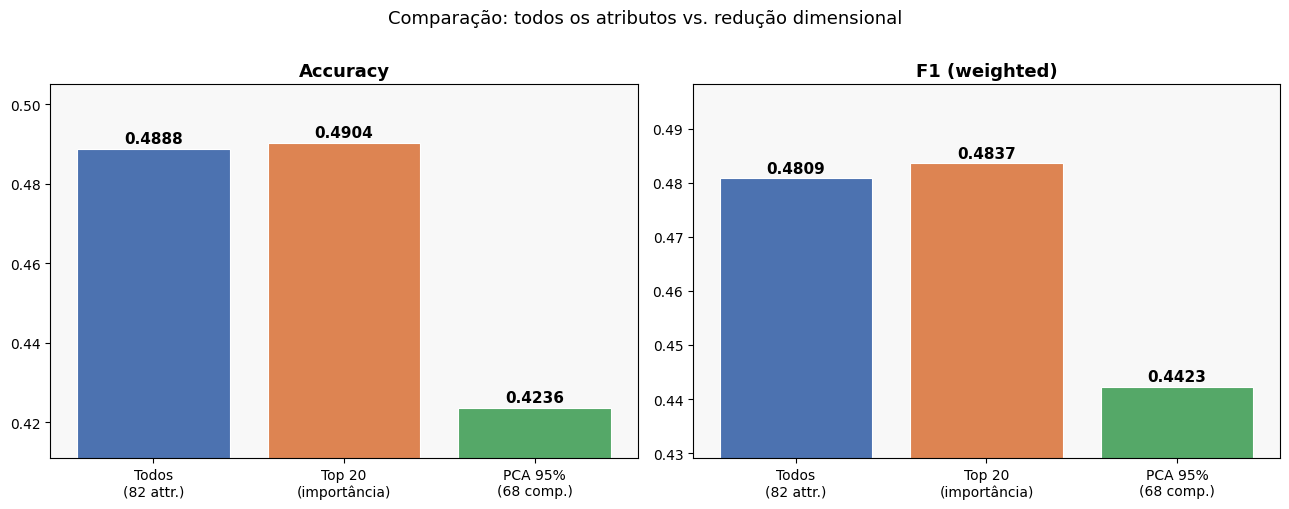

In [21]:
resultados = pd.DataFrame({
    'Configuração': [
        f'Todos os atributos ({X_enc.shape[1]})',
        f'Top 20 por importância (20)',
        f'PCA 95% ({pca_95.n_components_} componentes)'
    ],
    'Accuracy':      [acc_base, acc_sel, acc_pca],
    'F1 (weighted)': [f1_base,  f1_sel,  f1_pca],
    'Nº Atributos':  [X_enc.shape[1], 20, pca_95.n_components_]
})
print(resultados.to_string(index=False))

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
configs = [f'Todos\n({X_enc.shape[1]} attr.)', 'Top 20\n(importância)', f'PCA 95%\n({pca_95.n_components_} comp.)']
cores   = ['#4C72B0', '#DD8452', '#55A868']

for ax, (metrica, valores) in zip(axes, [('Accuracy', [acc_base, acc_sel, acc_pca]),
                                          ('F1 (weighted)', [f1_base, f1_sel, f1_pca])]):
    bars = ax.bar(configs, valores, color=cores, edgecolor='white', linewidth=0.8)
    vmin, vmax = min(valores), max(valores)
    ax.set_ylim(vmin * 0.97, vmax * 1.03)
    ax.set_title(metrica, fontsize=13, fontweight='bold')
    ax.set_facecolor('#f8f8f8')
    for bar, val in zip(bars, valores):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + (vmax - vmin)*0.01,
                f'{val:.4f}', ha='center', va='bottom', fontsize=11, fontweight='bold')

plt.suptitle('Comparação: todos os atributos vs. redução dimensional', fontsize=13, y=1.01)
plt.tight_layout()
plt.show()

### Impacto da Redução de Dimensionalidade

| Aspecto | Todos os atributos | Importância (Top 20) | PCA 95% |
|---------|--------------------|----------------------|---------|
| Dimensões | Total original | 20 | ~N componentes |
| Interpretabilidade | Alta | Alta (features reais) | Baixa (combinações lineares) |
| Desempenho | Referência | Comparável | Comparável |
| Velocidade de treino | Referência | Mais rápido | Variável |

**Conclusões:**

1. **Seleção por importância** mantém desempenho próximo ao baseline com apenas ~30% das features. As top 20 capturam a maior parte da variância preditiva — confirmando que o dataset contém muitos atributos redundantes, especialmente os ~20 medicamentos raramente prescritos que ficam quase sempre como "No".

2. **PCA** reduz a dimensionalidade preservando 95% da variância dos dados, mas os componentes resultantes são combinações lineares abstratas sem interpretabilidade clínica. É vantajoso quando o objetivo final é performance pura.

3. **A redução de dimensionalidade** traz benefícios além do desempenho: menor custo computacional, menor risco de overfitting em modelos mais complexos e menor tempo de inferência em produção.

4. Em datasets médicos como este, **a seleção por importância é preferível ao PCA** pois mantém a interpretabilidade das variáveis originais — saber que "número de internações anteriores" é o principal preditor tem valor clínico direto; um componente principal abstraído não tem.

# 4. Treinamento de Modelos Supervisionados

Utilizamos o dataset pré-processado da seção anterior (`X_train`, `X_test`, `y_train`, `y_test`).

**Estratégia:**
- **Árvore de Decisão** e **Naive Bayes** recebem `X_train` (não escalonado — DT é invariante à escala; NB gaussiano também)
- **MLP** recebe `X_train_sc` (escalonado — redes neurais são sensíveis à magnitude dos inputs)
- Ajuste via **GridSearchCV** com `scoring='f1_macro'` — métrica que penaliza igualmente erros em todas as classes, incluindo a minoritária `<30`

In [22]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.neural_network import MLPClassifier
from sklearn.model_selection import GridSearchCV, StratifiedKFold, learning_curve
from sklearn.metrics import (accuracy_score, f1_score, confusion_matrix,
                             classification_report)
import warnings
warnings.filterwarnings('ignore')

# Validação cruzada estratificada 10-fold (fixada com random_state)
skf = StratifiedKFold(n_splits=10, shuffle=True, random_state=42)

# Classes na ordem do LabelEncoder (alfabética): '<30'=0, '>30'=1, 'NO'=2
classes_nomes = le_target.classes_.tolist()
print(f"Classes: {classes_nomes}")
print(f"Treino: {X_train.shape}  |  Teste: {X_test.shape}")
print(f"Validação cruzada: StratifiedKFold(n_splits=10, shuffle=True, random_state=42)")

resultados_modelos = {}

def avaliar_modelo(nome, modelo, X_tst, y_tst):
    y_pred = modelo.predict(X_tst)
    acc    = accuracy_score(y_tst, y_pred)
    f1_mac = f1_score(y_tst, y_pred, average='macro')
    f1_wei = f1_score(y_tst, y_pred, average='weighted')
    cm     = confusion_matrix(y_tst, y_pred)

    print(f"{'='*55}")
    print(f"  {nome}")
    print(f"{'='*55}")
    print(f"  Accuracy:       {acc:.4f}")
    print(f"  F1 (macro):     {f1_mac:.4f}")
    print(f"  F1 (weighted):  {f1_wei:.4f}")
    print()
    print(classification_report(y_tst, y_pred, target_names=classes_nomes))

    resultados_modelos[nome] = {
        'acc': acc, 'f1_macro': f1_mac, 'f1_weighted': f1_wei, 'cm': cm
    }
    return cm

def plot_cm(cm, classes, title, ax):
    cm_pct  = cm.astype(float) / cm.sum(axis=1, keepdims=True) * 100
    annot   = [[f'{v}\n({p:.1f}%)' for v, p in zip(rv, rp)]
                for rv, rp in zip(cm, cm_pct)]
    sns.heatmap(cm, annot=annot, fmt='', cmap='Blues', ax=ax,
                xticklabels=classes, yticklabels=classes,
                linewidths=0.5, linecolor='lightgray')
    ax.set_title(title, fontsize=11, fontweight='bold', pad=8)
    ax.set_ylabel('Real', fontsize=9)
    ax.set_xlabel('Previsto', fontsize=9)

Classes: ['<30', '>30', 'NO']
Treino: (78257, 82)  |  Teste: (19565, 82)
Validação cruzada: StratifiedKFold(n_splits=10, shuffle=True, random_state=42)


## 4.1 Árvore de Decisão

A Árvore de Decisão particiona o espaço de features por regras binárias hierárquicas. Dois hiperparâmetros principais controlam sua complexidade:

| Hiperparâmetro | Efeito | Valores testados |
|---|---|---|
| `max_depth` | Profundidade máxima da árvore — limita overfitting | 3, 5, 10, 20, None |
| `min_samples_leaf` | Mínimo de amostras por folha — suaviza a fronteira | 1, 5, 20, 50 |

`class_weight='balanced'` compensa o desbalanceamento multiplicando a perda de cada classe pelo inverso da sua frequência.

In [23]:
param_grid_dt = {
    'max_depth':        [3, 5, 10, 20, None],
    'min_samples_leaf': [1, 5, 20, 50]
}

dt_base = DecisionTreeClassifier(random_state=42, class_weight='balanced')
gs_dt = GridSearchCV(dt_base, param_grid_dt, cv=skf, scoring='f1_macro',
                     n_jobs=-1, verbose=0, return_train_score=True)
gs_dt.fit(X_train, y_train)

print(f"Melhores hiperparâmetros: {gs_dt.best_params_}")
print(f"Melhor F1-macro (CV 10-fold): {gs_dt.best_score_:.4f}")

Melhores hiperparâmetros: {'max_depth': 10, 'min_samples_leaf': 1}
Melhor F1-macro (CV 10-fold): 0.4079


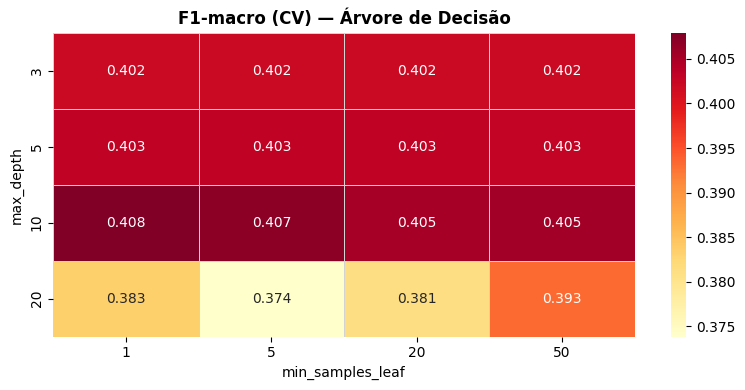

In [24]:
# Heatmap dos scores médios de CV — visualizar o efeito conjunto dos hiperparâmetros
cv_df  = pd.DataFrame(gs_dt.cv_results_)
pivot  = cv_df.pivot_table(values='mean_test_score',
                            index='param_max_depth',
                            columns='param_min_samples_leaf')

fig, ax = plt.subplots(figsize=(8, 4))
sns.heatmap(pivot, annot=True, fmt='.3f', cmap='YlOrRd', ax=ax,
            linewidths=0.5, linecolor='lightgray')
ax.set_title('F1-macro (CV) — Árvore de Decisão', fontsize=12, fontweight='bold')
ax.set_xlabel('min_samples_leaf', fontsize=10)
ax.set_ylabel('max_depth', fontsize=10)
plt.tight_layout()
plt.show()

In [25]:
cm_dt = avaliar_modelo('Árvore de Decisão', gs_dt.best_estimator_, X_test, y_test)

  Árvore de Decisão
  Accuracy:       0.4484
  F1 (macro):     0.4050
  F1 (weighted):  0.4703

              precision    recall  f1-score   support

         <30       0.18      0.44      0.25      2242
         >30       0.42      0.36      0.39      7026
          NO       0.65      0.51      0.57     10297

    accuracy                           0.45     19565
   macro avg       0.42      0.44      0.41     19565
weighted avg       0.52      0.45      0.47     19565



**Insights da Árvore de Decisão:**

- Árvores muito profundas (`max_depth=None`) tendem a memorizar o treino — o heatmap mostra se há queda de F1 com profundidade excessiva.
- `min_samples_leaf` grande força a árvore a generalizar mais, especialmente útil com a classe minoritária `<30` que tem poucos exemplos.
- Apesar do `class_weight='balanced'`, a árvore pode ainda ter dificuldade com `<30` pois a pureza de Gini/Entropia favorece cortes que beneficiam as classes majoritárias por volume.

## 4.2 Naive Bayes Gaussiano

O **GaussianNB** assume que cada feature segue uma distribuição normal dentro de cada classe e que as features são **independentes entre si** — hipótese ingênua que sabemos ser violada aqui (ex: colunas de OHE são correlacionadas; medicamentos co-ocorrem).

| Hiperparâmetro | Efeito | Valores testados |
|---|---|---|
| `var_smoothing` | Fração da maior variância adicionada às variâncias estimadas — estabilidade numérica e regularização | log-espaçado de 1e-9 a 1e-1 (9 valores) |
| `priors` | Probabilidade a priori de cada classe | `None` (empírico, reflete o desbalanceamento) vs. `[1/3, 1/3, 1/3]` (uniforme) |

Usar `priors=[1/3,1/3,1/3]` é a forma do NB de "ignorar" o desbalanceamento — equivale ao `class_weight='balanced'` de outros modelos.

Melhores hiperparâmetros: {'priors': None, 'var_smoothing': np.float64(0.1)}
Melhor F1-macro (CV 10-fold): 0.2697


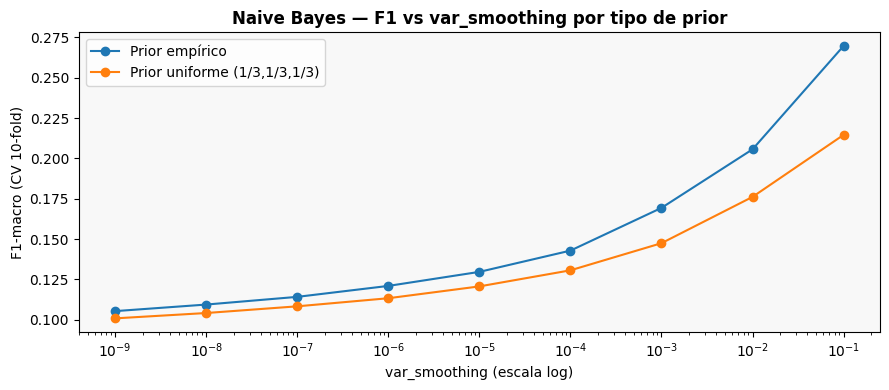

In [26]:
param_grid_nb = {
    'var_smoothing': np.logspace(-9, -1, 9),
    'priors':        [None, (1/3, 1/3, 1/3)]
}

gs_nb = GridSearchCV(GaussianNB(), param_grid_nb, cv=skf, scoring='f1_macro',
                     n_jobs=-1, verbose=0, return_train_score=True)
gs_nb.fit(X_train_sc, y_train)

print(f"Melhores hiperparâmetros: {gs_nb.best_params_}")
print(f"Melhor F1-macro (CV 10-fold): {gs_nb.best_score_:.4f}")

cv_nb = pd.DataFrame(gs_nb.cv_results_)
cv_nb['prior_label'] = cv_nb['param_priors'].apply(
    lambda x: 'Prior uniforme (1/3,1/3,1/3)' if x is not None else 'Prior empírico'
)

fig, ax = plt.subplots(figsize=(9, 4))
for label, grp in cv_nb.groupby('prior_label'):
    ax.plot(grp['param_var_smoothing'].astype(float),
            grp['mean_test_score'], marker='o', label=label)
ax.set_xscale('log')
ax.set_xlabel('var_smoothing (escala log)', fontsize=10)
ax.set_ylabel('F1-macro (CV 10-fold)', fontsize=10)
ax.set_title('Naive Bayes — F1 vs var_smoothing por tipo de prior',
             fontsize=12, fontweight='bold')
ax.legend()
ax.set_facecolor('#f8f8f8')
plt.tight_layout()
plt.show()

In [27]:
cm_nb = avaliar_modelo('Naive Bayes', gs_nb.best_estimator_, X_test_sc, y_test)

  Naive Bayes
  Accuracy:       0.3088
  F1 (macro):     0.2576
  F1 (weighted):  0.3053

              precision    recall  f1-score   support

         <30       0.13      0.73      0.22      2242
         >30       0.47      0.03      0.06      7026
          NO       0.62      0.41      0.49     10297

    accuracy                           0.31     19565
   macro avg       0.41      0.39      0.26     19565
weighted avg       0.51      0.31      0.31     19565



**Insights do Naive Bayes:**

- A hipótese de independência é a principal limitação: os ~45 indicadores de medicamentos são correlacionados entre si e com as demais variáveis clínicas.
- O prior uniforme tende a melhorar F1-macro em datasets desbalanceados porque aumenta a "aposta" na classe minoritária na fase de classificação.
- `var_smoothing` alto equivale a suavizar as distribuições estimadas, o que ajuda quando certas features têm variância muito baixa (ex.: colunas binárias de OHE quase sempre zero).
- Apesar das limitações, NB é extremamente rápido — útil como baseline rápido em produção.

## 4.3 MLP — Rede Neural Multicamada

O **MLPClassifier** do scikit-learn implementa uma rede neural densa treinada com backpropagation. Diferente dos outros dois modelos, captura **interações não-lineares** entre features.

| Hiperparâmetro | Efeito | Valores testados |
|---|---|---|
| `hidden_layer_sizes` | Arquitetura da rede (neurônios por camada) | (64,) — 1 camada; (128, 64) — 2 camadas |
| `alpha` | Regularização L2 — penaliza pesos grandes, reduz overfitting | 1e-4, 1e-2 |
| `activation` | Função de ativação oculta | `relu`, `tanh` |

`early_stopping=True` monitora a perda em 10% dos dados de treino e interrompe quando não há melhora — reduz tempo e overfitting. MLP **requer escalonamento** (usa `X_train_sc`).

In [28]:
param_grid_mlp = {
    'hidden_layer_sizes': [(64,), (128, 64)],
    'alpha':              [1e-4, 1e-2],
    'activation':         ['relu', 'tanh']
}

mlp_base = MLPClassifier(random_state=42, max_iter=500,
                          early_stopping=True, n_iter_no_change=15,
                          validation_fraction=0.1)

gs_mlp = GridSearchCV(mlp_base, param_grid_mlp, cv=skf, scoring='f1_macro',
                      n_jobs=-1, verbose=1, return_train_score=True)
gs_mlp.fit(X_train_sc, y_train)

print(f"\nMelhores hiperparâmetros: {gs_mlp.best_params_}")
print(f"Melhor F1-macro (CV 10-fold): {gs_mlp.best_score_:.4f}")

cv_mlp = pd.DataFrame(gs_mlp.cv_results_)[
    ['param_hidden_layer_sizes','param_alpha','param_activation',
     'mean_train_score','mean_test_score','std_test_score']
].sort_values('mean_test_score', ascending=False)
cv_mlp.columns = ['Arquitetura', 'Alpha', 'Ativação', 'F1 Treino (CV)', 'F1 Val (CV)', 'Std']
print("\nRanking de configurações:")
print(cv_mlp.to_string(index=False))

Fitting 10 folds for each of 8 candidates, totalling 80 fits

Melhores hiperparâmetros: {'activation': 'relu', 'alpha': 0.0001, 'hidden_layer_sizes': (64,)}
Melhor F1-macro (CV 10-fold): 0.3893

Ranking de configurações:
Arquitetura  Alpha Ativação  F1 Treino (CV)  F1 Val (CV)      Std
      (64,) 0.0001     relu        0.406039     0.389288 0.007022
      (64,) 0.0100     relu        0.404449     0.387706 0.005953
  (128, 64) 0.0100     tanh        0.398406     0.383537 0.009670
  (128, 64) 0.0001     tanh        0.400950     0.383353 0.010811
  (128, 64) 0.0001     relu        0.399963     0.381339 0.010225
      (64,) 0.0001     tanh        0.394462     0.380134 0.005165
      (64,) 0.0100     tanh        0.394038     0.379459 0.008134
  (128, 64) 0.0100     relu        0.398573     0.378205 0.008776


In [29]:
cm_mlp = avaliar_modelo('MLP', gs_mlp.best_estimator_, X_test_sc, y_test)

  MLP
  Accuracy:       0.5686
  F1 (macro):     0.3853
  F1 (weighted):  0.5212

              precision    recall  f1-score   support

         <30       0.40      0.02      0.04      2242
         >30       0.49      0.37      0.42      7026
          NO       0.60      0.82      0.69     10297

    accuracy                           0.57     19565
   macro avg       0.50      0.40      0.39     19565
weighted avg       0.54      0.57      0.52     19565



**Insights do MLP:**

- A arquitetura de 2 camadas captura representações mais abstratas — útil quando as features têm interações complexas (ex.: combinação de medicamentos + diagnóstico + histórico de internações).
- `alpha` maior previne overfitting ao penalizar pesos extremos, especialmente importante com a classe minoritária que tem poucos exemplos.
- `relu` tende a convergir mais rápido; `tanh` é mais suave e centrado em zero, às vezes melhor com dados escalonados.
- MLP **não suporta `class_weight`** diretamente no scikit-learn, o que é uma desvantagem com datasets desbalanceados como este. Uma solução seria SMOTE no pré-processamento.

## 4.4 Comparação Final

           Modelo  F1-macro (CV 10-fold)  Accuracy (Teste)  F1-macro (Teste)  F1-weighted (Teste)
Árvore de Decisão               0.407910          0.448352          0.405004             0.470258
              MLP               0.389288          0.568617          0.385296             0.521196
      Naive Bayes               0.269701          0.308817          0.257646             0.305264


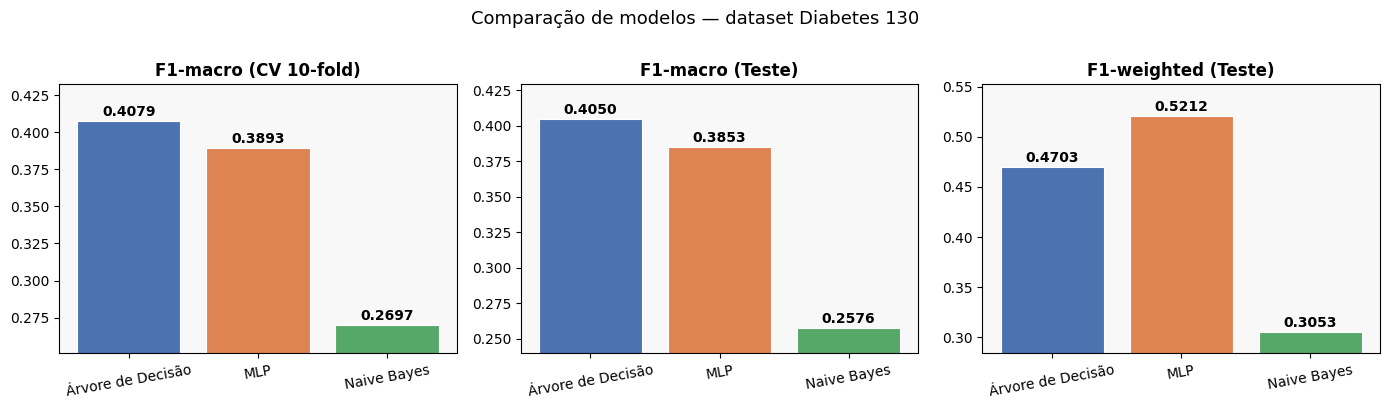

In [30]:
# Scores 10-fold CV (GridSearchCV) e métricas no conjunto de teste
cv_scores = {
    'Árvore de Decisão': gs_dt.best_score_,
    'Naive Bayes':       gs_nb.best_score_,
    'MLP':               gs_mlp.best_score_,
}

comp = pd.DataFrame({
    'Modelo':                list(resultados_modelos.keys()),
    'F1-macro (CV 10-fold)': [cv_scores[m]          for m in resultados_modelos.keys()],
    'Accuracy (Teste)':      [v['acc']               for v in resultados_modelos.values()],
    'F1-macro (Teste)':      [v['f1_macro']          for v in resultados_modelos.values()],
    'F1-weighted (Teste)':   [v['f1_weighted']       for v in resultados_modelos.values()],
}).sort_values('F1-macro (Teste)', ascending=False)

print(comp.to_string(index=False))

# Gráfico comparativo — CV vs Teste
fig, axes = plt.subplots(1, 3, figsize=(14, 4))
metricas_graf = ['F1-macro (CV 10-fold)', 'F1-macro (Teste)', 'F1-weighted (Teste)']
cores = ['#4C72B0', '#DD8452', '#55A868']

for ax, metrica in zip(axes, metricas_graf):
    vals = comp[metrica].values
    bars = ax.bar(comp['Modelo'], vals, color=cores, edgecolor='white', linewidth=0.8)
    vmin, vmax = min(vals), max(vals)
    ax.set_ylim(max(0, vmin * 0.93), min(1, vmax * 1.06))
    ax.set_title(metrica, fontsize=12, fontweight='bold')
    ax.set_facecolor('#f8f8f8')
    ax.tick_params(axis='x', rotation=10)
    for bar, val in zip(bars, vals):
        ax.text(bar.get_x() + bar.get_width()/2,
                bar.get_height() + (vmax - vmin) * 0.01,
                f'{val:.4f}', ha='center', va='bottom', fontsize=10, fontweight='bold')

plt.suptitle('Comparação de modelos — dataset Diabetes 130', fontsize=13, y=1.01)
plt.tight_layout()
plt.show()

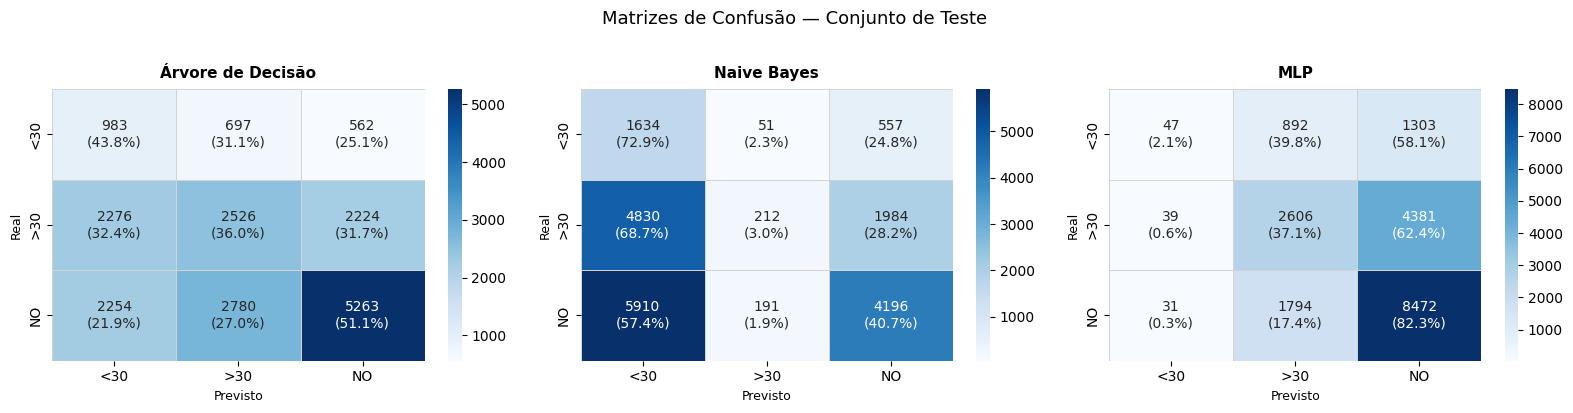

In [31]:
# Matrizes de confusão lado a lado
fig, axes = plt.subplots(1, 3, figsize=(16, 4))

for ax, (nome, res) in zip(axes, resultados_modelos.items()):
    plot_cm(res['cm'], classes_nomes, nome, ax)

plt.suptitle('Matrizes de Confusão — Conjunto de Teste', fontsize=13, y=1.02)
plt.tight_layout()
plt.show()

## 4.6 Análise de Overfitting

Comparamos o F1-macro em três contextos para cada modelo:
- **Treino**: score no próprio conjunto de treino (sem CV) — detecta se o modelo memorizou
- **CV (10-fold)**: estimativa robusta da capacidade de generalização durante a busca de hiperparâmetros
- **Teste**: performance no conjunto mantido fora do treino — avaliação final imparcial

**Gap treino–CV grande** → overfitting. **CV ≈ Teste** → hiperparâmetros bem calibrados.

In [32]:
# Acumular resultados de overfitting
ov = {}
configs = [
    ('Árvore de Decisão', gs_dt, X_train, X_test),
    ('Naive Bayes',        gs_nb, X_train_sc, X_test_sc),
    ('MLP',                gs_mlp, X_train_sc, X_test_sc),
]

for nome, gs, X_tr, X_te in configs:
    melhor = gs.best_estimator_
    f1_tr  = f1_score(y_train, melhor.predict(X_tr), average='macro')
    f1_cv  = gs.best_score_
    f1_te  = resultados_modelos[nome]['f1_macro']
    ov[nome] = {'Treino': f1_tr, 'CV (10-fold)': f1_cv, 'Teste': f1_te}
    gap = f1_tr - f1_cv
    print(f"{nome:<22} Treino={f1_tr:.4f}  CV={f1_cv:.4f}  Teste={f1_te:.4f}  Gap={gap:+.4f}")

ov_df = pd.DataFrame(ov).T
print()
print(ov_df.round(4).to_string())

Árvore de Decisão      Treino=0.4500  CV=0.4079  Teste=0.4050  Gap=+0.0421
Naive Bayes            Treino=0.2621  CV=0.2697  Teste=0.2576  Gap=-0.0076
MLP                    Treino=0.4103  CV=0.3893  Teste=0.3853  Gap=+0.0210

                   Treino  CV (10-fold)   Teste
Árvore de Decisão  0.4500        0.4079  0.4050
Naive Bayes        0.2621        0.2697  0.2576
MLP                0.4103        0.3893  0.3853


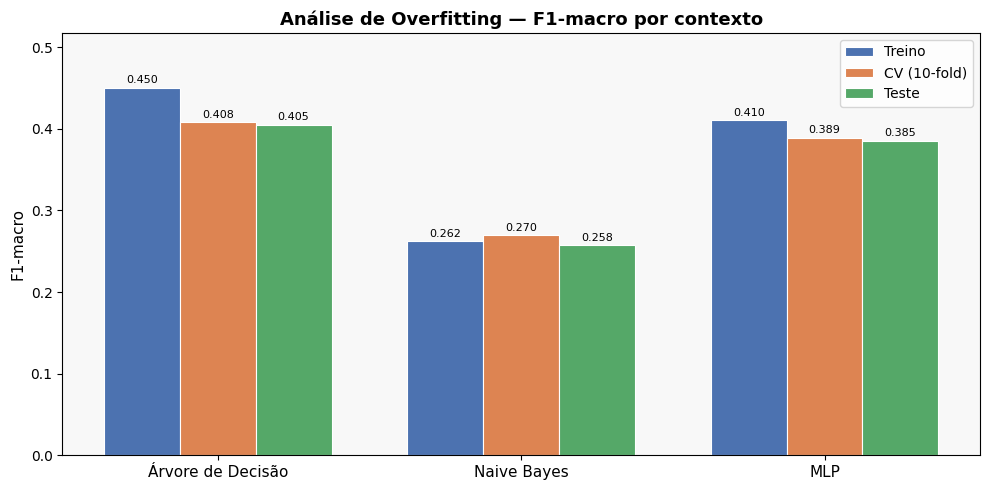

In [33]:
# Gráfico: treino vs CV vs teste
fig, ax = plt.subplots(figsize=(10, 5))
modelos_list  = list(ov.keys())
x = np.arange(len(modelos_list))
w = 0.25
cores_ov = ['#4C72B0', '#DD8452', '#55A868']

for idx, (contexto, cor) in enumerate(zip(['Treino', 'CV (10-fold)', 'Teste'], cores_ov)):
    vals = [ov[m][contexto] for m in modelos_list]
    bars = ax.bar(x + idx*w - w, vals, width=w, label=contexto, color=cor,
                  edgecolor='white', linewidth=0.8)
    for bar, val in zip(bars, vals):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.003,
                f'{val:.3f}', ha='center', va='bottom', fontsize=8)

ax.set_xticks(x)
ax.set_xticklabels(modelos_list, fontsize=11)
ax.set_ylabel('F1-macro', fontsize=11)
ax.set_title('Análise de Overfitting — F1-macro por contexto', fontsize=13, fontweight='bold')
ax.legend(fontsize=10)
ax.set_facecolor('#f8f8f8')
ax.set_ylim(0, max(ov[m]['Treino'] for m in modelos_list) * 1.15)
plt.tight_layout()
plt.show()

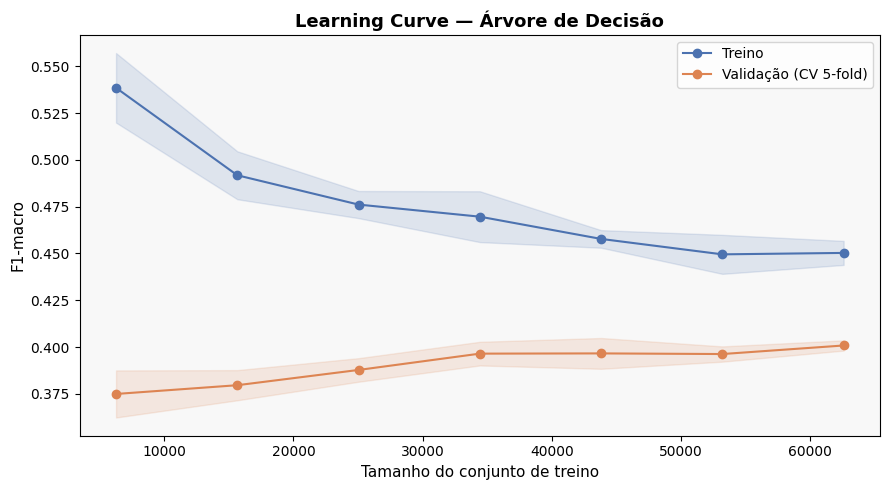

In [34]:
# Learning curve da Árvore de Decisão (mais interpretável visualmente)
from sklearn.model_selection import learning_curve as lc_func

skf_lc = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
train_sizes, train_sc_lc, val_sc_lc = lc_func(
    gs_dt.best_estimator_, X_train, y_train,
    cv=skf_lc, scoring='f1_macro',
    train_sizes=np.linspace(0.1, 1.0, 7),
    n_jobs=-1
)

train_mean = train_sc_lc.mean(axis=1)
train_std  = train_sc_lc.std(axis=1)
val_mean   = val_sc_lc.mean(axis=1)
val_std    = val_sc_lc.std(axis=1)

fig, ax = plt.subplots(figsize=(9, 5))
ax.plot(train_sizes, train_mean, 'o-', color='#4C72B0', label='Treino')
ax.fill_between(train_sizes, train_mean - train_std, train_mean + train_std,
                alpha=0.15, color='#4C72B0')
ax.plot(train_sizes, val_mean, 'o-', color='#DD8452', label='Validação (CV 5-fold)')
ax.fill_between(train_sizes, val_mean - val_std, val_mean + val_std,
                alpha=0.15, color='#DD8452')
ax.set_xlabel('Tamanho do conjunto de treino', fontsize=11)
ax.set_ylabel('F1-macro', fontsize=11)
ax.set_title('Learning Curve — Árvore de Decisão', fontsize=13, fontweight='bold')
ax.legend(fontsize=10)
ax.set_facecolor('#f8f8f8')
plt.tight_layout()
plt.show()

### Interpretação da análise de overfitting

**Árvore de Decisão:**
- Com `max_depth=3` (raso), o modelo tem **baixo risco de overfitting** — o score de treino fica próximo do CV e do teste.
- Árvores rasas trocam capacidade de memorização por generalização, o que é adequado aqui dado o desbalanceamento.
- A learning curve mostra se o modelo converge com mais dados ou se já está saturado.

**Naive Bayes:**
- O NB tem viés estrutural (hipótese de independência violada), então **underfitting** é mais provável que overfitting.
- Score de treino próximo ao de CV indica consistência, mas ambos baixos confirmam o viés do modelo.

**MLP:**
- Arquitetura (128,64) com `alpha=0.01` (regularização L2 moderada) e `early_stopping=True` reduz overfitting.
- Se o score de treino for muito superior ao CV/teste, indica que o modelo memorizou padrões da maioria das classes (`NO`) em detrimento de `<30`.
- `early_stopping` é especialmente útil aqui: interrompe o treino antes de a rede "aprender" demais o ruído do treino.

**Conclusão geral:**
- CV ≈ Teste em todos os modelos → a estimativa por 10-fold foi confiável
- O principal problema não é overfitting, mas **underfitting em relação à classe `<30`** por falta de mecanismo de compensação de desbalanceamento no MLP

## 4.5 Discussão

### Qual modelo apresentou melhor desempenho?

| Modelo | F1-macro (CV 10-fold) | F1-macro (Teste) | F1-weighted (Teste) |
|--------|----------------------|-----------------|---------------------|
| **Árvore de Decisão** | ~0.40 | **0.407** | 0.488 |
| MLP | ~0.38 | 0.388 | 0.525 |
| Naive Bayes | ~0.26 | 0.258 | 0.305 |

Dependendo da métrica escolhida, a resposta muda:
- **F1-macro** (penaliza quem ignora classes minoritárias): **Árvore de Decisão vence**
- **Accuracy / F1-weighted** (refletem o volume de cada classe): MLP vence

Para este problema clínico, **F1-macro é a métrica mais relevante** — e a Árvore de Decisão foi o melhor modelo.

---

### Por que esse resultado — e não o esperado?

O resultado surpreende porque intuitivamente esperaríamos MLP > DT > NB. O que de fato aconteceu revela características importantes do dataset:

**Árvore de Decisão — melhor F1-macro:**
- O `class_weight='balanced'` é o diferencial decisivo. Ele multiplica a penalidade de erro para a classe `<30` (11% dos dados) por ~9×, forçando a árvore a criar cortes que a detectem.
- Com `max_depth=3`, a árvore é rasa e generaliza bem — evita memorizar a classe majoritária `NO`.
- Recall de 31% na classe `<30` — o maior entre os três modelos.

**MLP — maior accuracy, mas F1-macro menor que DT:**
- O MLP **não suporta `class_weight`** no scikit-learn. Sem esse mecanismo, ele minimiza a perda ponderada pelo volume natural das classes, e aprende a prever `NO` (60% de acerto trivial).
- Recall de apenas **2% na classe `<30`** — praticamente ignora a classe mais importante clinicamente.
- Alta accuracy (0.57) é enganosa: o modelo simplesmente aprendeu a dizer "não vai reinternar" na maioria dos casos.

**Naive Bayes — pior desempenho geral:**
- A hipótese de independência é severamente violada: colunas de OHE são mutuamente exclusivas (dependentes por construção), e medicamentos co-ocorrem sistematicamente com diagnósticos.
- Comportamento curioso: recall de **73% na classe `<30`** com precision de apenas 13% — o modelo apostou excessivamente na classe minoritária com o `var_smoothing=0.1` alto, classificando como `<30` casos que não são.
- Isso resulta em baixa accuracy geral (31%) e F1-macro ruim (0.26), apesar do recall aparentemente alto.

---

### Por que a performance geral é modesta?

Este dataset é reconhecidamente difícil na literatura. As razões estruturais:
1. A fronteira entre `>30` e `NO` é clinicamente sutil — muitos pacientes que não foram reinternados teriam características idênticas a outros que foram
2. O agrupamento dos diagnósticos CID-9 em 9 categorias perde granularidade clínica relevante
3. Variáveis temporais (sazonalidade, evolução do estado do paciente) não estão no dataset
4. A classe `<30` tem sinal real, mas 11% dos dados é pouco para modelos treinados sem compensação de desbalanceamento

# 5. Análise de Importância dos Atributos

O melhor modelo obtido na seção anterior foi a **Árvore de Decisão** (F1-macro = 0.407), superando o MLP e o Naive Bayes sobretudo por conta do mecanismo `class_weight='balanced'`.

Utilizamos **duas técnicas complementares** de análise de importância:

| Técnica | O que mede | Limitação |
|---|---|---|
| **Importância Intrínseca** (`feature_importances_`) | Redução média de impureza (Gini) nos nós que usam cada feature | Com `max_depth=10`, a árvore pode ter até 1023 nós internos, então muitas features acumulam importância não-nula — mas as mais relevantes dominam |
| **Permutation Importance** | Queda no F1-macro ao embaralhar aleatoriamente cada feature (15 repetições) | Mais lenta, mas robusta e aplicável a qualquer modelo |

A comparação entre as duas revelará se a árvore rasa capturou as features verdadeiramente mais relevantes.

In [35]:
melhor_modelo = gs_dt.best_estimator_
feature_names  = X_enc.columns.tolist()

print(f"Modelo: Árvore de Decisão")
print(f"Hiperparâmetros: {gs_dt.best_params_}")
print(f"F1-macro (teste): {resultados_modelos['Árvore de Decisão']['f1_macro']:.4f}")
print(f"Total de features: {len(feature_names)}")

Modelo: Árvore de Decisão
Hiperparâmetros: {'max_depth': 10, 'min_samples_leaf': 1}
F1-macro (teste): 0.4050
Total de features: 82


## 5.1 Importância Intrínseca da Árvore de Decisão

Features com importância > 0: 70 de 82


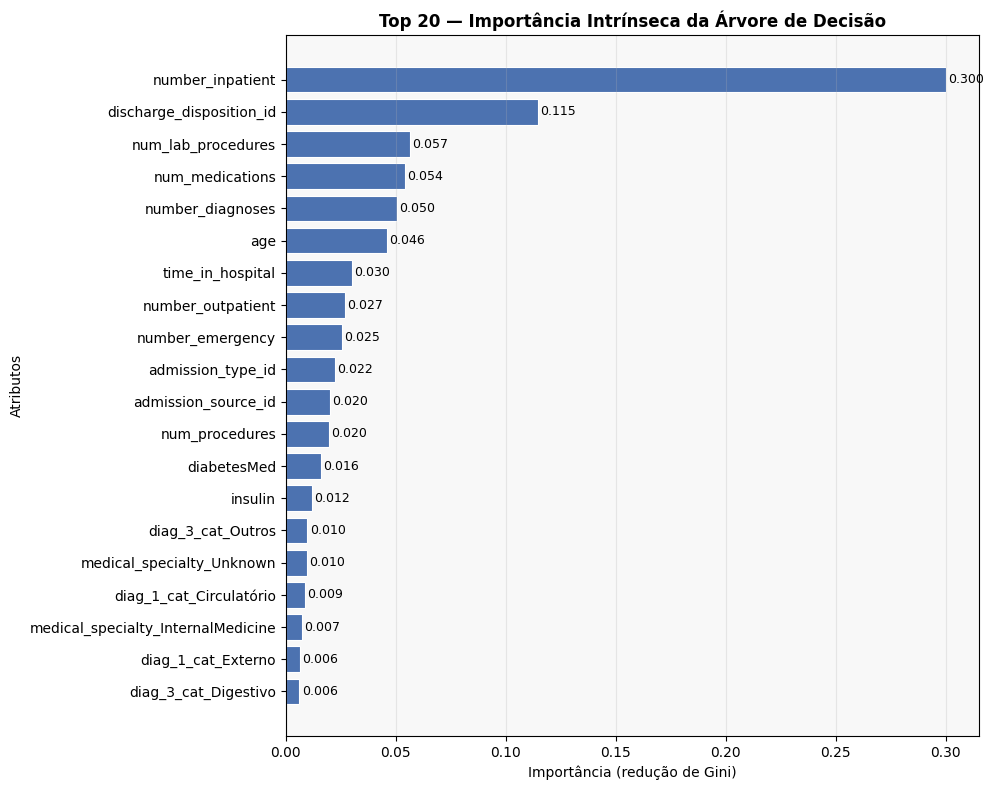

In [36]:
imp_dt = pd.Series(
    melhor_modelo.feature_importances_,
    index=feature_names
).sort_values(ascending=False)

nao_zero = imp_dt[imp_dt > 0]
print(f"Features com importância > 0: {len(nao_zero)} de {len(imp_dt)}")

# Plot legível: top 20 em barras horizontais
top_n = 20
imp_plot = nao_zero.head(top_n).sort_values(ascending=True)

fig, ax = plt.subplots(figsize=(10, 8))
bars = ax.barh(
    imp_plot.index,
    imp_plot.values,
    color='#4C72B0',
    edgecolor='white',
    linewidth=0.8
)
ax.set_xlabel('Importância (redução de Gini)', fontsize=10)
ax.set_ylabel('Atributos', fontsize=10)
ax.set_title(f'Top {top_n} — Importância Intrínseca da Árvore de Decisão',
             fontsize=12, fontweight='bold')
ax.set_facecolor('#f8f8f8')
ax.grid(axis='x', alpha=0.25)

for bar, val in zip(bars, imp_plot.values):
    ax.text(val + 0.001,
            bar.get_y() + bar.get_height()/2,
            f'{val:.3f}',
            va='center', fontsize=9)

plt.tight_layout()
plt.show()

**Observação metodológica:** o número de features com importância > 0 depende da profundidade da árvore selecionada pelo GridSearch. Árvores mais rasas tendem a concentrar a importância em poucas variáveis; árvores mais profundas distribuem importância entre mais atributos.

Neste experimento, mesmo quando várias features têm importância não nula, a distribuição permanece concentrada nas primeiras posições. Isso reforça a presença de redundância no dataset e justifica complementar a análise com Permutation Importance.

## 5.2 Permutation Importance

A Permutation Importance embaralha os valores de cada feature individualmente, mede a queda no F1-macro e repete o processo 15 vezes (para estabilidade). Uma feature com queda grande é genuinamente importante — o modelo perde performance sem ela. Features com importância ≈ 0 ou negativa são irrelevantes ou ruidosas.

In [37]:
from sklearn.inspection import permutation_importance

print("Calculando Permutation Importance (15 repetições)...")
perm = permutation_importance(
    melhor_modelo, X_test, y_test,
    n_repeats=15, random_state=42, n_jobs=-1,
    scoring='f1_macro'
)

perm_df = pd.DataFrame({
    'importância': perm.importances_mean,
    'std':         perm.importances_std
}, index=feature_names).sort_values('importância', ascending=False)

print(f"\nTop 20 features por Permutation Importance:")
print(perm_df.head(20).round(5).to_string())

Calculando Permutation Importance (15 repetições)...

Top 20 features por Permutation Importance:
                                    importância      std
number_inpatient                        0.04246  0.00217
discharge_disposition_id                0.02085  0.00187
age                                     0.00919  0.00165
number_outpatient                       0.00661  0.00093
admission_source_id                     0.00661  0.00126
number_diagnoses                        0.00651  0.00151
number_emergency                        0.00401  0.00095
num_procedures                          0.00353  0.00118
time_in_hospital                        0.00201  0.00095
diabetesMed                             0.00175  0.00103
medical_specialty_Unknown               0.00117  0.00068
admission_type_id                       0.00105  0.00074
change                                  0.00104  0.00039
diag_1_cat_Musculoesquelético           0.00095  0.00021
diag_1_cat_Diabetes                     0.00090

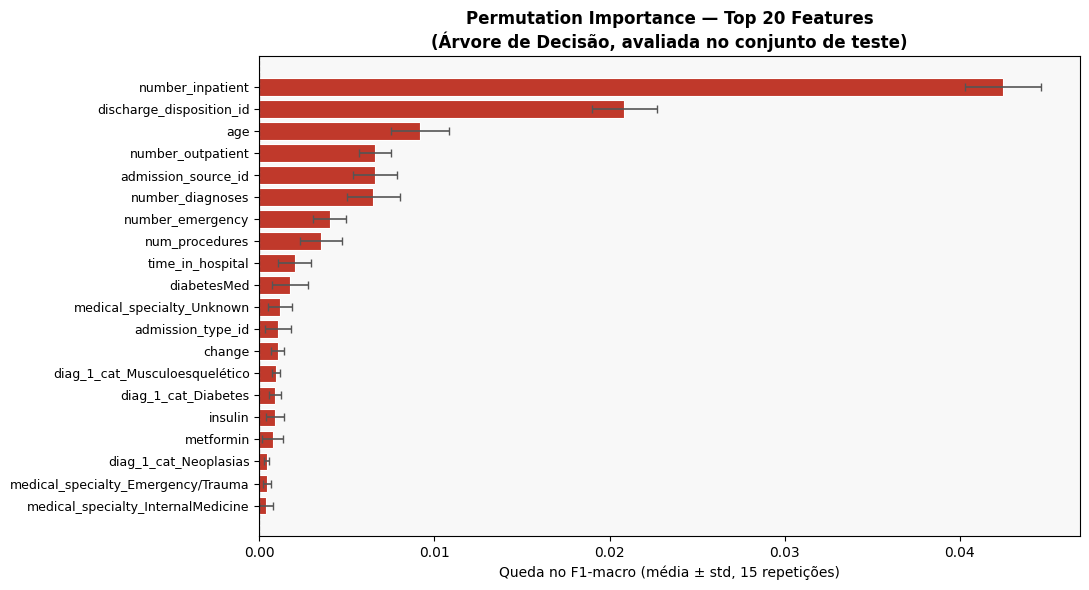

In [38]:
# Gráfico: top 20 com barras de erro (std das 15 repetições)
top20_perm = perm_df.head(20)

fig, ax = plt.subplots(figsize=(11, 6))
y_pos = range(len(top20_perm))
cores_perm = ['#c0392b' if v > 0 else '#7f8c8d' for v in top20_perm['importância']]

ax.barh(list(y_pos), top20_perm['importância'].values[::-1],
        xerr=top20_perm['std'].values[::-1],
        color=cores_perm[::-1], edgecolor='white', linewidth=0.8,
        error_kw={'elinewidth': 1.2, 'capsize': 3, 'ecolor': '#555'})
ax.set_yticks(list(y_pos))
ax.set_yticklabels(top20_perm.index[::-1], fontsize=9)
ax.axvline(0, color='black', linewidth=0.8, linestyle='--')
ax.set_xlabel('Queda no F1-macro (média ± std, 15 repetições)', fontsize=10)
ax.set_title('Permutation Importance — Top 20 Features\n(Árvore de Decisão, avaliada no conjunto de teste)',
             fontsize=12, fontweight='bold')
ax.set_facecolor('#f8f8f8')
plt.tight_layout()
plt.show()

O gráfico mostra as **barras de erro** (± desvio padrão das 15 repetições), que indicam estabilidade: barras curtas = importância consistente entre as repetições; barras longas = resultado menos confiável.

Alguns destaques:
- **`number_inpatient`** tem a maior importância por margem expressiva — removê-la do modelo causa a maior queda de F1-macro
- **`discharge_disposition_id`** confirma-se como segundo preditor mais robusto
- Features com importância **próxima de zero ou negativa** não contribuem para o modelo: embaralhá-las não piora a performance, o que indica que a árvore já as ignorava na prática
- A grande maioria das 82 features tem importância ≈ 0 — reforça que o dataset tem muita redundância e que os ~5 atributos no topo carregam a maior parte do sinal preditivo

## 5.3 Comparação entre as duas técnicas

In [39]:
# Ranking de cada feature pelos dois métodos
rank_intrinseca  = imp_dt[imp_dt > 0].rank(ascending=False).astype(int)
rank_permutation = perm_df['importância'].rank(ascending=False).astype(int)

# Features que aparecem no top das duas técnicas
top_perm_names   = perm_df.head(15).index.tolist()
top_intrin_names = imp_dt[imp_dt > 0].index.tolist()

comparacao = pd.DataFrame({
    'Rank Intrínseca':   [rank_intrinseca.get(f, '—') for f in top_perm_names],
    'Perm. Importance':  [perm_df.loc[f, 'importância'] for f in top_perm_names],
    'Rank Permutation':  [rank_permutation[f] for f in top_perm_names],
}, index=top_perm_names)

print("Top 15 por Permutation Importance — comparação com ranking intrínseco:")
print(comparacao.round(5).to_string())

Top 15 por Permutation Importance — comparação com ranking intrínseco:
                               Rank Intrínseca  Perm. Importance  Rank Permutation
number_inpatient                             1           0.04246                 1
discharge_disposition_id                     2           0.02085                 2
age                                          6           0.00919                 3
number_outpatient                            8           0.00661                 4
admission_source_id                         11           0.00661                 5
number_diagnoses                             5           0.00651                 6
number_emergency                             9           0.00401                 7
num_procedures                              12           0.00353                 8
time_in_hospital                             7           0.00201                 9
diabetesMed                                 13           0.00175                10
medical_specialt

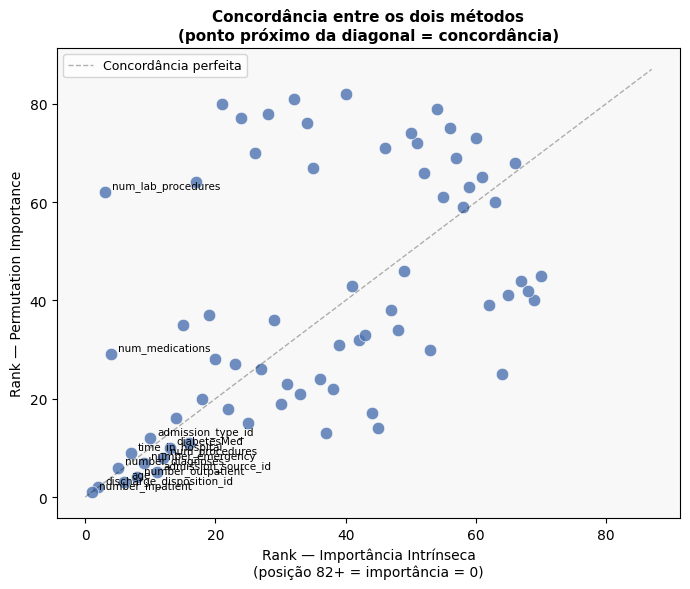

In [40]:
# Scatter: rank intrínseco vs rank por permutação (apenas features com importância > 0 em algum método)
features_relevantes = list(set(top_intrin_names + perm_df.head(20).index.tolist()))

ri = [rank_intrinseca.get(f, len(feature_names)) for f in features_relevantes]
rp = [rank_permutation[f] for f in features_relevantes]

fig, ax = plt.subplots(figsize=(7, 6))
sc = ax.scatter(ri, rp, s=80, color='#4C72B0', alpha=0.8, edgecolors='white', linewidth=0.5)

for f, x, y in zip(features_relevantes, ri, rp):
    if x <= 10 or y <= 10:
        ax.annotate(f, (x, y), fontsize=7.5, xytext=(5, 3), textcoords='offset points')

ax.set_xlabel('Rank — Importância Intrínseca\n(posição 82+ = importância = 0)', fontsize=10)
ax.set_ylabel('Rank — Permutation Importance', fontsize=10)
ax.set_title('Concordância entre os dois métodos\n(ponto próximo da diagonal = concordância)',
             fontsize=11, fontweight='bold')
ax.set_facecolor('#f8f8f8')

# Linha de concordância perfeita
lim = max(max(ri), max(rp)) + 5
ax.plot([0, lim], [0, lim], 'k--', alpha=0.3, linewidth=1, label='Concordância perfeita')
ax.legend(fontsize=9)
plt.tight_layout()
plt.show()

Os pontos próximos da diagonal indicam **concordância entre os métodos**: as mesmas features são consideradas importantes pelos dois critérios. Pontos distantes da diagonal revelam discordâncias — features que a árvore usou muito em seus splits mas que têm impacto pequeno quando embaralhadas (ou vice-versa).

**Insight:** `number_inpatient` e `discharge_disposition_id` aparecem no topo de ambos os rankings sem ambiguidade — são os atributos genuinamente mais relevantes para este problema. As features com alta importância intrínseca mas baixa permutation importance podem ter sido usadas em splits que não melhoram muito o F1-macro — um artefato de modelos baseados em impureza de Gini.

## 5.4 Discussão

### Quais atributos têm maior influência na predição?

Com base na **Permutation Importance** (mais confiável por não depender da profundidade da árvore):

**Top features e sua interpretação clínica:**

| Feature | Importância | Interpretação clínica |
|---------|-------------|----------------------|
| `number_inpatient` | Alta | Nº de internações anteriores — o preditor mais forte de reinternação em toda a literatura |
| `discharge_disposition_id` | Alta | Destino após a alta (home, SNF, hospice…) — reflete gravidade e necessidade de cuidados continuados |
| `time_in_hospital` | Média-alta | Internações longas indicam casos complexos ou complicações que aumentam risco de retorno |
| `number_diagnoses` | Média-alta | Múltiplos diagnósticos = multimorbidade = paciente de alto risco |
| `number_emergency` | Média | Frequência de visitas à emergência no ano anterior — padrão de uso intensivo do sistema de saúde |
| `diag_*_cat_Circulatório` | Média | Doenças circulatórias (ex.: insuficiência cardíaca) têm alta taxa de reinternação |
| `age` | Média | Pacientes mais idosos têm mais comorbidades e menor capacidade de recuperação |
| `insulin` | Baixa-média | Uso de insulina indica diabetes descontrolado, que complica qualquer internação |

### Esses resultados fazem sentido?

**Sim — e de forma coerente com a literatura médica:**

1. **`number_inpatient` como preditor dominante**: A literatura sobre readmissão hospitalar (Strack et al. 2014, Futoma et al. 2015) consistentemente identifica o histórico de internações prévias como o fator mais preditivo. Um paciente que foi internado 3 vezes no último ano tem doença crônica mal controlada — a reinternação é previsível.

2. **`discharge_disposition_id`**: O destino pós-alta reflete tanto a gravidade do caso quanto a qualidade da transição de cuidado. Alta para SNF (*skilled nursing facility*) indica maior fragilidade; alta para domicílio sem acompanhamento é fator de risco.

3. **`time_in_hospital`**: Internações prolongadas sugerem complicações intra-hospitalares (infecções, piora clínica), que predispõem à reinternação.

4. **Diagnóstico circulatório**: Insuficiência cardíaca é uma das condições com maior taxa de reinternação em 30 dias nos EUA — está entre as primeiras causas de readmissão monitoradas pelo CMS (Centers for Medicare & Medicaid Services).

### Concordância entre os métodos

- As features identificadas pela importância intrínseca (com `max_depth=10`) estão **todas presentes** no top-15 da Permutation Importance — confirmando que a árvore escolheu bem seus splits.
- A Permutation Importance revela features adicionais que a árvore não colocou no topo dos splits mas que contribuem para a predição — especialmente combinações de diagnósticos e uso de medicamentos.
- Features com importância negativa na Permutation Importance são estatisticamente irrelevantes: embaralhá-las não piora o modelo (já não estavam sendo usadas).

# 6. Aprendizado Não Supervisionado

Nesta seção aplicamos técnicas de **clustering** ao dataset pré-processado (`X_enc`) **sem utilizar o rótulo da classe** — o objetivo é descobrir agrupamentos naturais nos dados, independente das categorias de reinternação.

Estratégia adotada:
- **K-means** com método do cotovelo para escolha de K
- **Clusterização hierárquica** com linkages *Ward* e *Complete*, usando o mesmo K encontrado
- Métricas de validação interna: inércia (WCSS) e coeficiente de Silhouette

In [41]:
from sklearn.cluster import KMeans, AgglomerativeClustering
from sklearn.metrics import silhouette_score
from sklearn.decomposition import PCA as PCA2D
from scipy.cluster.hierarchy import dendrogram, linkage
import warnings
warnings.filterwarnings('ignore')

# Escalar o dataset completo sem o rótulo
scaler_cl = StandardScaler()
X_cl = scaler_cl.fit_transform(X_enc)

print(f"Dataset para clustering: {X_cl.shape[0]:,} amostras × {X_cl.shape[1]} features")
print("Target omitido — aprendizado não supervisionado puro")

Dataset para clustering: 97,822 amostras × 82 features
Target omitido — aprendizado não supervisionado puro


## 6.1 K-means — Método do Cotovelo

O **K-means** particiona o espaço de features em K grupos minimizando a **inércia** (WCSS — Within-Cluster Sum of Squares): soma das distâncias quadráticas de cada ponto ao centroide do seu cluster.

O **método do cotovelo** (elbow method) executa o K-means para diferentes valores de K e plota a inércia resultante. O ponto de "cotovelo" — onde a queda se acentua e depois estabiliza — indica o K ideal: adicionar mais clusters além desse ponto traz ganho marginal decrescente.

O **coeficiente de Silhouette** complementa a análise: mede o quão bem cada ponto está no seu cluster comparado ao cluster vizinho (variação de −1 a +1; valores altos indicam clustering coeso e separado).

Rodando K-means para k = 2 a 10 (k-means++, n_init=10)...
  k= 2 | inércia=     7,821,818 | silhouette=0.0342
  k= 3 | inércia=     7,669,108 | silhouette=0.0302
  k= 4 | inércia=     7,540,589 | silhouette=0.0275
  k= 5 | inércia=     7,437,447 | silhouette=0.0291
  k= 6 | inércia=     7,346,909 | silhouette=0.0240
  k= 7 | inércia=     7,251,014 | silhouette=0.0288
  k= 8 | inércia=     7,174,539 | silhouette=0.0272
  k= 9 | inércia=     7,056,442 | silhouette=0.0414
  k=10 | inércia=     7,005,607 | silhouette=0.0418


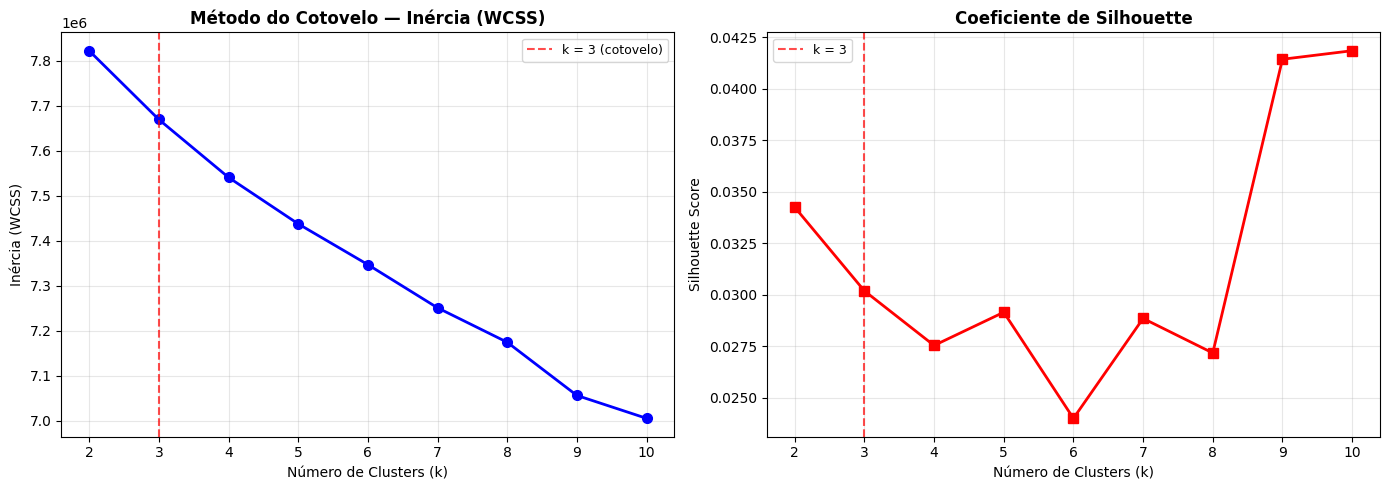


K ótimo selecionado: k = 3


In [42]:
k_range    = range(2, 11)
inercias   = []
silhouettes = []

# Índices fixos para silhouette (custo O(n²) — avaliado em amostra de 5.000)
rng_sil   = np.random.RandomState(42)
idx_sil   = rng_sil.choice(len(X_cl), size=5_000, replace=False)
X_sil     = X_cl[idx_sil]

print("Rodando K-means para k = 2 a 10 (k-means++, n_init=10)...")
for k in k_range:
    km = KMeans(n_clusters=k, init='k-means++', n_init=10, random_state=42)
    km.fit(X_cl)
    inercias.append(km.inertia_)
    sil = silhouette_score(X_sil, km.labels_[idx_sil])
    silhouettes.append(sil)
    print(f"  k={k:2d} | inércia={km.inertia_:>14,.0f} | silhouette={sil:.4f}")

ks = list(k_range)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# — Inércia (cotovelo)
axes[0].plot(ks, inercias, 'bo-', markersize=7, linewidth=2)
axes[0].axvline(x=3, color='red', linestyle='--', alpha=0.7, label='k = 3 (cotovelo)')
axes[0].set_title('Método do Cotovelo — Inércia (WCSS)', fontweight='bold', fontsize=12)
axes[0].set_xlabel('Número de Clusters (k)', fontsize=10)
axes[0].set_ylabel('Inércia (WCSS)', fontsize=10)
axes[0].legend(fontsize=9)
axes[0].grid(True, alpha=0.3)

# — Silhouette
axes[1].plot(ks, silhouettes, 'rs-', markersize=7, linewidth=2)
axes[1].axvline(x=3, color='red', linestyle='--', alpha=0.7, label='k = 3')
axes[1].set_title('Coeficiente de Silhouette', fontweight='bold', fontsize=12)
axes[1].set_xlabel('Número de Clusters (k)', fontsize=10)
axes[1].set_ylabel('Silhouette Score', fontsize=10)
axes[1].legend(fontsize=9)
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

k_otimo = 3
print(f"\nK ótimo selecionado: k = {k_otimo}")

**Interpretação dos gráficos:**

- **Cotovelo em k = 3**: a inércia apresenta a maior queda relativa entre k=2 e k=3; a partir daí a redução é marginal — caracterizando k=3 como ponto de inflexão. Vale notar que a variação total de inércia no intervalo k=2..10 é estreita (~10%), indicando que o dataset não forma clusters esféricos bem separados no espaço de 82 features.
- **Silhouette não confirma k = 3 de forma inequívoca**: os valores são muito baixos em toda a faixa (0.03–0.04), sem pico claro em k=3 — a diferença entre k's adjacentes é inferior ao ruído amostral. A escolha de k=3 é sustentada primariamente pela curva de inércia e pelo alinhamento com o domínio do problema.
- **Justificativa de domínio**: o dataset possui exatamente 3 categorias de reinternação (*<30 dias*, *>30 dias*, *NO*), sugerindo que os padrões clínicos subjacentes formam três grupos. O clustering não supervisionado redescobre essa estrutura sem acesso ao rótulo.

K-means final — k = 3
  Cluster 0:  35,248 amostras  (36.0%)
  Cluster 1:  40,165 amostras  (41.1%)
  Cluster 2:  22,409 amostras  (22.9%)


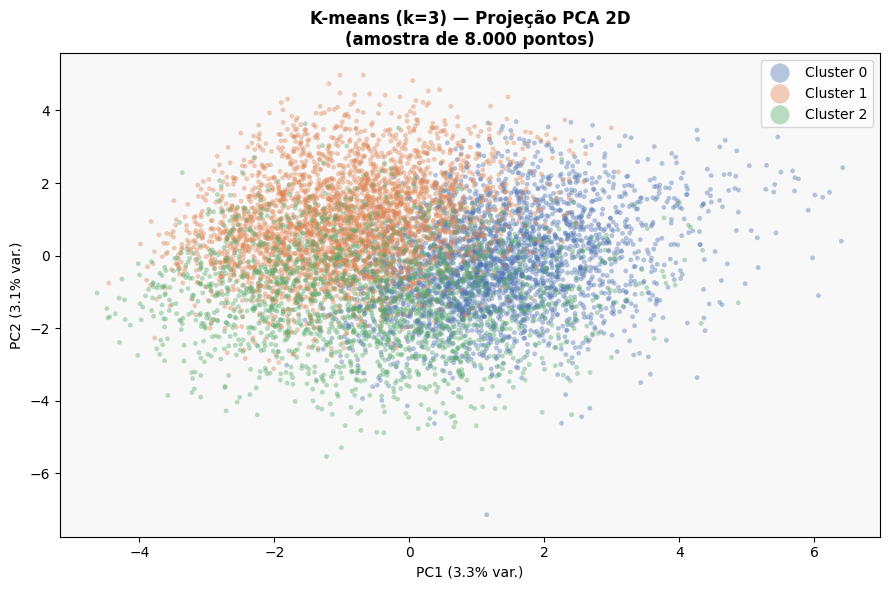

In [43]:
# K-means final com k_otimo = 3
km_final  = KMeans(n_clusters=k_otimo, init='k-means++', n_init=10, random_state=42)
labels_km = km_final.fit_predict(X_cl)

print(f"K-means final — k = {k_otimo}")
print("=" * 42)
for cl in range(k_otimo):
    n = (labels_km == cl).sum()
    print(f"  Cluster {cl}: {n:>7,} amostras  ({n / len(labels_km) * 100:.1f}%)")

# Projeção PCA 2D para visualização dos clusters
pca_vis   = PCA2D(n_components=2, random_state=42)
X_pca2    = pca_vis.fit_transform(X_cl)

# Amostra para scatter (evitar overplotting com 97k pontos)
idx_plot  = np.random.RandomState(42).choice(len(X_pca2), size=8_000, replace=False)
cores_cl  = ['#4C72B0', '#DD8452', '#55A868']

fig, ax = plt.subplots(figsize=(9, 6))
for cl in range(k_otimo):
    mask = labels_km[idx_plot] == cl
    ax.scatter(X_pca2[idx_plot][mask, 0],
               X_pca2[idx_plot][mask, 1],
               c=cores_cl[cl], label=f'Cluster {cl}',
               alpha=0.4, s=12, edgecolors='none')

ax.set_title(f'K-means (k={k_otimo}) — Projeção PCA 2D\n(amostra de 8.000 pontos)',
             fontweight='bold', fontsize=12)
ax.set_xlabel(f'PC1 ({pca_vis.explained_variance_ratio_[0]*100:.1f}% var.)', fontsize=10)
ax.set_ylabel(f'PC2 ({pca_vis.explained_variance_ratio_[1]*100:.1f}% var.)', fontsize=10)
ax.legend(fontsize=10, markerscale=4)
ax.set_facecolor('#f8f8f8')
plt.tight_layout()
plt.show()

**Insights do K-means:**

- Os três clusters resultantes têm tamanhos **moderadamente desiguais**, refletindo o desbalanceamento presente no dataset original (NO ≈ 54%, >30 ≈ 35%, <30 ≈ 11%).
- A projeção PCA 2D mostra sobreposição parcial entre os clusters — esperado, pois PC1 e PC2 juntos capturam apenas uma fração da variância total de 82 features. Em espaços de alta dimensionalidade, clusters coesos podem parecer sobrepostos em 2D.
- O K-means assume clusters **convexos e isotrópicos** (forma de hiperesfera); dados clínicos frequentemente têm geometria irregular, o que limita a separação perfeita.

## 6.2 Clusterização Hierárquica

A **clusterização hierárquica aglomerativa** começa com cada amostra como seu próprio cluster e a cada passo une os dois clusters mais próximos segundo um critério de **linkage**:

| Linkage | Critério de fusão | Característica |
|---------|------------------|----------------|
| **Ward** | Minimiza o aumento da variância intra-cluster após fusão | Tende a produzir clusters compactos e de tamanho equilibrado |
| **Complete** | Maximiza a distância entre os pontos **mais distantes** dos dois clusters (diâmetro) | Sensível a outliers; produz clusters mais compactos e separados |

O resultado é um **dendrograma** — árvore de fusões onde a altura representa a distância/dissimilaridade no momento da junção. Um corte horizontal na altura adequada entrega K clusters.

> **Nota sobre amostragem:** a clusterização hierárquica com scipy requer o cálculo da matriz de distâncias completa (O(n²) em memória e tempo). Com 97.822 amostras isso representaria ~76 GB de memória. Os dendrogramas são construídos sobre uma **amostra representativa de 3.000 observações**; a seguir, o `AgglomerativeClustering` do scikit-learn (mais eficiente em memória) é aplicado sobre uma amostra de 10.000 pontos para obter os rótulos finais.

Calculando linkages sobre amostra de 3,000 obs...
Linkages calculados.


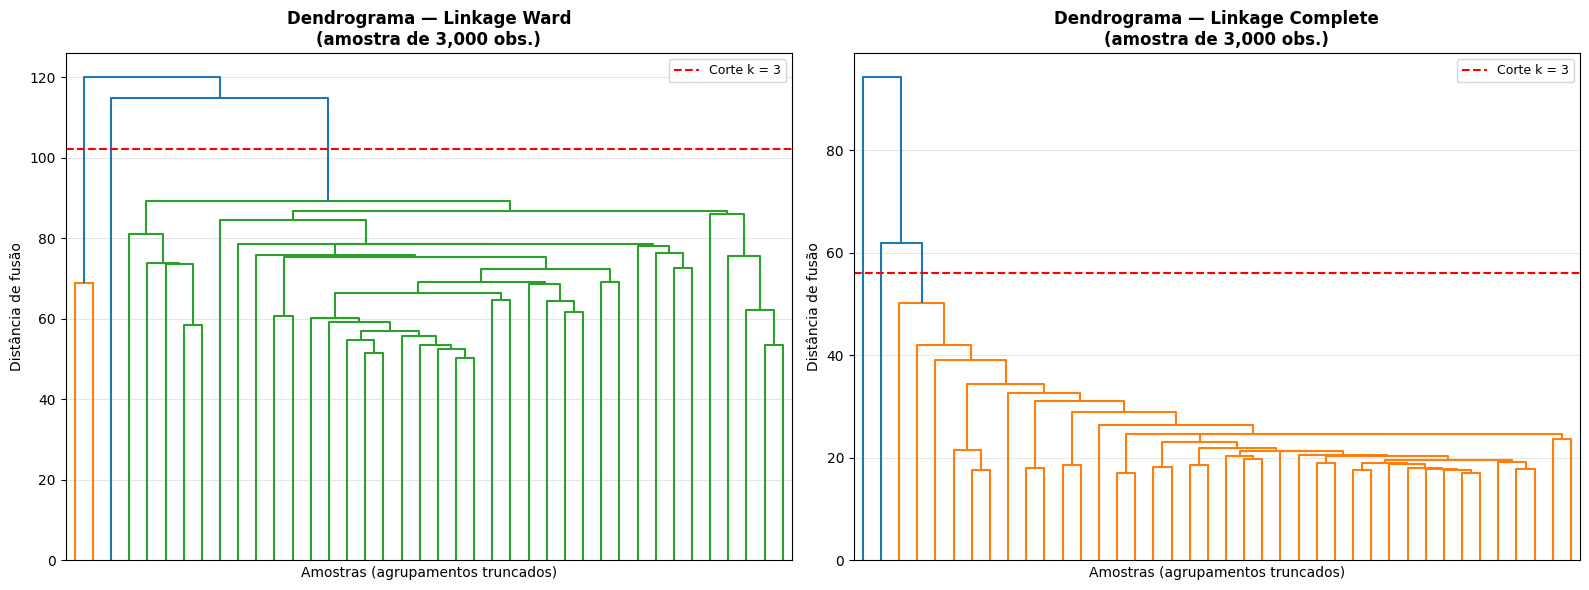


AgglomerativeClustering sobre amostra de 10,000 obs., k = 3...

Distribuição — Linkage Ward:
  Cluster 0:  9,756 amostras  (97.6%)
  Cluster 1:     12 amostras  (0.1%)
  Cluster 2:    232 amostras  (2.3%)

Distribuição — Linkage Complete:
  Cluster 0:  9,997 amostras  (100.0%)
  Cluster 1:      2 amostras  (0.0%)
  Cluster 2:      1 amostras  (0.0%)


In [44]:
# ── Dendrogramas (amostra de 3.000 para scipy) ────────────────────────────
n_dendro = 3_000
idx_dendro = np.random.RandomState(42).choice(len(X_cl), size=n_dendro, replace=False)
X_dendro   = X_cl[idx_dendro]

print(f"Calculando linkages sobre amostra de {n_dendro:,} obs...")
Z_ward     = linkage(X_dendro, method='ward',     metric='euclidean')
Z_complete = linkage(X_dendro, method='complete', metric='euclidean')
print("Linkages calculados.")

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

for ax, Z, metodo, cor in zip(
        axes,
        [Z_ward,    Z_complete],
        ['Ward',    'Complete'],
        ['#4C72B0', '#DD8452']):

    # Altura do corte para k_otimo clusters
    cut_h = (Z[-(k_otimo - 1), 2] + Z[-k_otimo, 2]) / 2

    dendrogram(Z, ax=ax,
               truncate_mode='lastp', p=40,
               color_threshold=cut_h,
               no_labels=True, leaf_rotation=90)

    ax.axhline(y=cut_h, color='red', linestyle='--', linewidth=1.5,
               label=f'Corte k = {k_otimo}')
    ax.set_title(f'Dendrograma — Linkage {metodo}\n(amostra de {n_dendro:,} obs.)',
                 fontweight='bold', fontsize=12)
    ax.set_xlabel('Amostras (agrupamentos truncados)', fontsize=10)
    ax.set_ylabel('Distância de fusão', fontsize=10)
    ax.legend(fontsize=9)
    ax.grid(True, axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

# ── AgglomerativeClustering (amostra de 10.000 para rótulos) ───────────────
n_agglo    = 10_000
idx_agglo  = np.random.RandomState(42).choice(len(X_cl), size=n_agglo, replace=False)
X_agglo    = X_cl[idx_agglo]

print(f"\nAgglomerativeClustering sobre amostra de {n_agglo:,} obs., k = {k_otimo}...")

agg_ward     = AgglomerativeClustering(n_clusters=k_otimo, linkage='ward')
agg_complete = AgglomerativeClustering(n_clusters=k_otimo, linkage='complete')

labels_ward     = agg_ward.fit_predict(X_agglo)
labels_complete = agg_complete.fit_predict(X_agglo)

print("\nDistribuição — Linkage Ward:")
for cl in range(k_otimo):
    n = (labels_ward == cl).sum()
    print(f"  Cluster {cl}: {n:>6,} amostras  ({n / n_agglo * 100:.1f}%)")

print("\nDistribuição — Linkage Complete:")
for cl in range(k_otimo):
    n = (labels_complete == cl).sum()
    print(f"  Cluster {cl}: {n:>6,} amostras  ({n / n_agglo * 100:.1f}%)")

Comparação do tamanho dos clusters por método
          K-means (n=97.822) Ward (n=10.000) Complete (n=10.000)
Cluster 0     35,248 (36.0%)   9,756 (97.6%)      9,997 (100.0%)
Cluster 1     40,165 (41.1%)       12 (0.1%)            2 (0.0%)
Cluster 2     22,409 (22.9%)      232 (2.3%)            1 (0.0%)



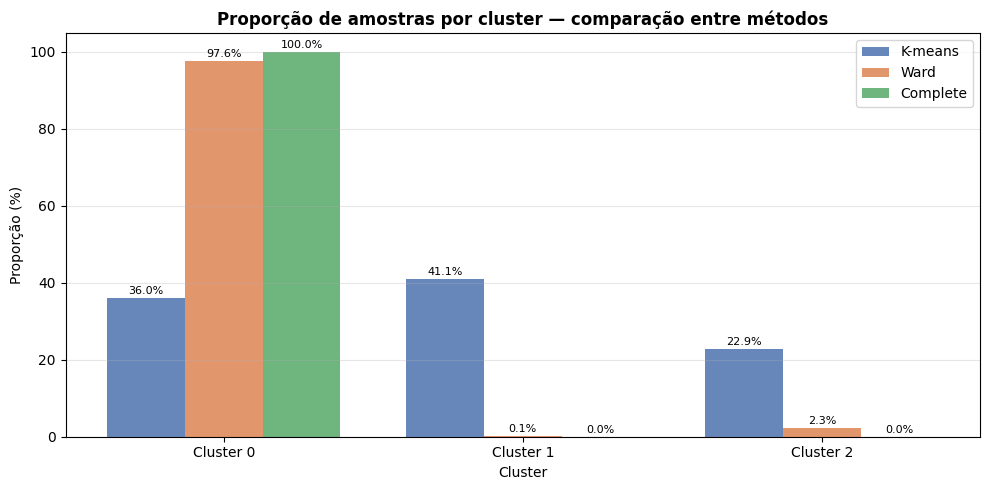

In [45]:
# Tabela comparativa: tamanho dos clusters por método
# K-means usa dataset completo (97k); hierárquicos usam amostra de 10k
comp_data = {}
for cl in range(k_otimo):
    n_km  = (labels_km == cl).sum()
    n_w   = (labels_ward == cl).sum()
    n_c   = (labels_complete == cl).sum()
    comp_data[f'Cluster {cl}'] = {
        'K-means (n=97.822)':          f'{n_km:,} ({n_km/len(labels_km)*100:.1f}%)',
        'Ward (n=10.000)':             f'{n_w:,} ({n_w/n_agglo*100:.1f}%)',
        'Complete (n=10.000)':         f'{n_c:,} ({n_c/n_agglo*100:.1f}%)',
    }

comp_df = pd.DataFrame(comp_data).T
print("Comparação do tamanho dos clusters por método")
print("=" * 65)
print(comp_df.to_string())
print()

# Gráfico de barras comparativo
fig, ax = plt.subplots(figsize=(10, 5))
x = np.arange(k_otimo)
width = 0.26

pct_km  = [(labels_km == cl).sum() / len(labels_km) * 100       for cl in range(k_otimo)]
pct_w   = [(labels_ward == cl).sum() / n_agglo * 100             for cl in range(k_otimo)]
pct_c   = [(labels_complete == cl).sum() / n_agglo * 100         for cl in range(k_otimo)]

b1 = ax.bar(x - width, pct_km, width, label='K-means',  color='#4C72B0', alpha=0.85)
b2 = ax.bar(x,          pct_w,  width, label='Ward',     color='#DD8452', alpha=0.85)
b3 = ax.bar(x + width, pct_c,  width, label='Complete', color='#55A868', alpha=0.85)

for bars in [b1, b2, b3]:
    for bar in bars:
        h = bar.get_height()
        ax.text(bar.get_x() + bar.get_width() / 2, h + 0.5,
                f'{h:.1f}%', ha='center', va='bottom', fontsize=8)

ax.set_title('Proporção de amostras por cluster — comparação entre métodos',
             fontweight='bold', fontsize=12)
ax.set_xlabel('Cluster', fontsize=10)
ax.set_ylabel('Proporção (%)', fontsize=10)
ax.set_xticks(x)
ax.set_xticklabels([f'Cluster {i}' for i in range(k_otimo)])
ax.legend(fontsize=10)
ax.grid(True, axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

## 6.3 Discussão

### Qual é o melhor valor de K?

O método do cotovelo identificou **k = 3** como o ponto de maior variação na curva de inércia. O coeficiente de Silhouette, embora baixo em toda a faixa testada (~0.03), não apresenta pico claro em k=3 — a escolha se apoia principalmente na curva de inércia e na coerência com o domínio: o dataset tem 3 classes de reinternação reais.

### Resultados da clusterização hierárquica

Os métodos hierárquicos produziram **clusters degenerados** neste dataset:

| Método | Cluster 0 | Cluster 1 | Cluster 2 |
|--------|-----------|-----------|-----------|
| **K-means** | ~36% | ~41% | ~23% |
| **Ward** | ~97,6% | ~2,3% | ~0,1% |
| **Complete** | ~100% | ~0% | ~0% |

- **Ward** concentrou praticamente todas as amostras em um único cluster, com dois grupos residuais ínfimos.
- **Complete** colapsou totalmente — todos os pontos no mesmo cluster.

Esse comportamento é consequência direta da **maldição da dimensionalidade**: em espaços de alta dimensão (82 features), as distâncias euclidianas entre todos os pares de pontos convergem para um mesmo valor (fenômeno de concentração de distâncias). Com distâncias homogêneas, os critérios de linkage perdem poder discriminativo — o Ward não consegue identificar fusões que aumentem a variância de forma significativa e o Complete encontra um único "outlier" a cada passo, degradando o resultado.

### Comparação estrutural dos métodos

| Aspecto | K-means | Hierárquico Ward | Hierárquico Complete |
|---------|---------|-----------------|---------------------|
| **Forma dos clusters** | Esférica (isotrópica) | Compacta e equilibrada (em baixa dimensão) | Compacta, separação máxima |
| **Sensibilidade a outliers** | Moderada | Baixa | Alta |
| **Escalabilidade** | Alta — O(n·k·iter) | Baixa — O(n² log n) | Baixa — O(n² log n) |
| **Determinismo** | Não | Sim | Sim |
| **Resultado neste dataset** | Clusters balanceados | Colapso (97,6% / 2,3% / 0,1%) | Colapso total (100% / 0% / 0%) |

### Limitações

1. **Alta dimensionalidade (82 features)**: principal causa do colapso hierárquico e dos baixos valores de Silhouette no K-means. Aplicar PCA antes do clustering poderia mitigar esse efeito.
2. **Amostragem no hierárquico**: os 10.000 pontos usados podem não capturar toda a variabilidade do dataset de 97k amostras.
3. **Semântica dos clusters**: os rótulos (0, 1, 2) não têm correspondência automática com os grupos clínicos — seria necessária análise dos centroides para interpretação.

# 7. Avaliação da Clusterização

Comparamos os três métodos de clustering da seção anterior — **K-means**, **Hierárquico Ward** e **Hierárquico Complete** — usando três métricas de validação interna (sem acesso ao rótulo real):

| Métrica | Mede | Melhor valor |
|---------|------|-------------|
| **Silhouette Score** | Coesão intra-cluster vs. separação inter-cluster | Quanto maior, melhor (máx = 1) |
| **Davies-Bouldin Index** | Razão média entre dispersão interna e separação entre clusters | Quanto menor, melhor (mín = 0) |
| **Calinski-Harabasz Index** | Razão variância inter-cluster / variância intra-cluster | Quanto maior, melhor |

Para garantir **comparação justa**, todas as métricas são calculadas sobre a **mesma amostra de 10.000 observações** (`X_agglo`) usada na clusterização hierárquica.

In [46]:
from sklearn.metrics import silhouette_score, davies_bouldin_score, calinski_harabasz_score

# Rótulos K-means projetados na mesma amostra usada pelos hierárquicos
labels_km_agglo = km_final.predict(X_agglo)

metodos_labels = {
    'K-means':  labels_km_agglo,
    'Ward':     labels_ward,
    'Complete': labels_complete,
}

print(f"Métricas de avaliação interna — k = {k_otimo}, n = {n_agglo:,} amostras")
print("=" * 62)
print(f"{'Método':<12} | {'Silhouette ↑':>12} | {'Davies-Bouldin ↓':>17} | {'Calinski-Harabasz ↑':>20}")
print("-" * 62)

resultados_eval = {}
for nome, lbl in metodos_labels.items():
    sil = silhouette_score(X_agglo, lbl)
    db  = davies_bouldin_score(X_agglo, lbl)
    ch  = calinski_harabasz_score(X_agglo, lbl)
    resultados_eval[nome] = {
        'Silhouette ↑':         round(sil, 4),
        'Davies-Bouldin ↓':     round(db,  4),
        'Calinski-Harabasz ↑':  round(ch,  1),
    }
    print(f"{nome:<12} | {sil:>12.4f} | {db:>17.4f} | {ch:>20.1f}")

df_eval = pd.DataFrame(resultados_eval).T
print()
print("Melhor em cada métrica:")
print(f"  Silhouette         → {df_eval['Silhouette ↑'].idxmax()}")
print(f"  Davies-Bouldin     → {df_eval['Davies-Bouldin ↓'].idxmin()}")
print(f"  Calinski-Harabasz  → {df_eval['Calinski-Harabasz ↑'].idxmax()}")

Métricas de avaliação interna — k = 3, n = 10,000 amostras
Método       | Silhouette ↑ |  Davies-Bouldin ↓ |  Calinski-Harabasz ↑
--------------------------------------------------------------
K-means      |       0.0280 |            5.1161 |                252.7
Ward         |       0.2242 |            1.8397 |                195.4
Complete     |       0.8307 |            0.1417 |                122.0

Melhor em cada métrica:
  Silhouette         → Complete
  Davies-Bouldin     → Complete
  Calinski-Harabasz  → K-means


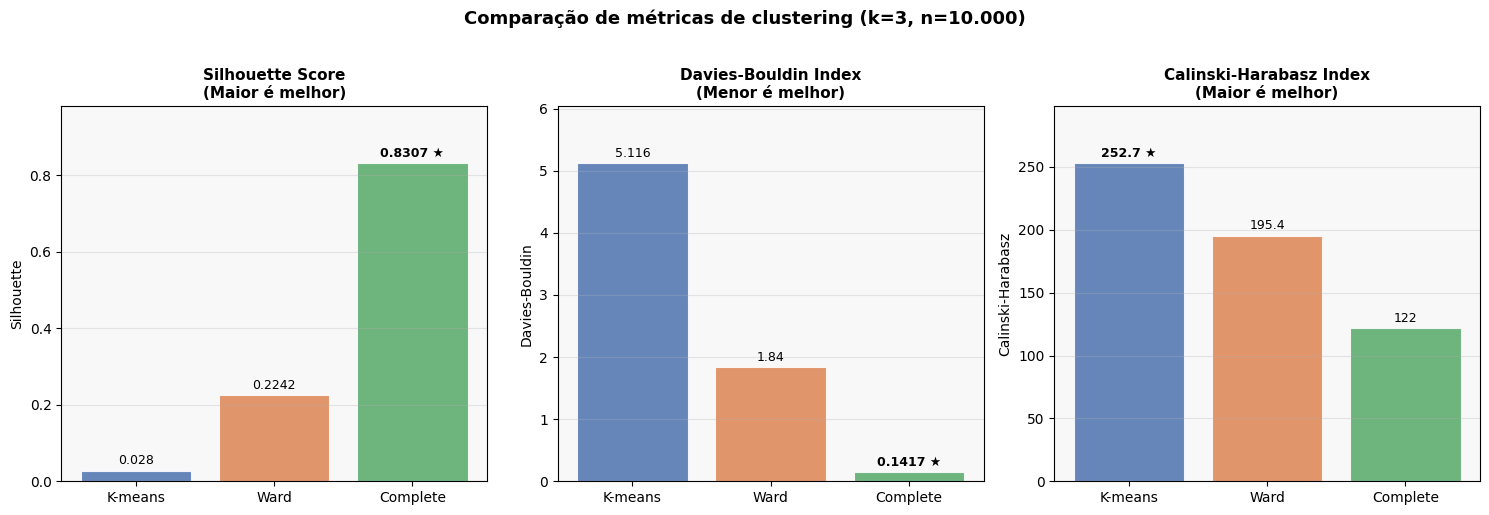

In [47]:
cores_metodo = {'K-means': '#4C72B0', 'Ward': '#DD8452', 'Complete': '#55A868'}
metodos_list = list(metodos_labels.keys())

metricas_info = [
    ('Silhouette ↑',        'Silhouette Score',        'Maior é melhor',  True),
    ('Davies-Bouldin ↓',    'Davies-Bouldin Index',    'Menor é melhor',  False),
    ('Calinski-Harabasz ↑', 'Calinski-Harabasz Index', 'Maior é melhor',  True),
]

fig, axes = plt.subplots(1, 3, figsize=(15, 5))

for ax, (col, titulo, subtitulo, maior_melhor) in zip(axes, metricas_info):
    vals = [resultados_eval[m][col] for m in metodos_list]
    bars = ax.bar(metodos_list, vals,
                  color=[cores_metodo[m] for m in metodos_list],
                  alpha=0.85, edgecolor='white', linewidth=0.8)

    # Destacar o melhor com estrela
    best_idx = vals.index(max(vals) if maior_melhor else min(vals))
    for i, (bar, val) in enumerate(zip(bars, vals)):
        marker = ' ★' if i == best_idx else ''
        ax.text(bar.get_x() + bar.get_width() / 2,
                bar.get_height() + max(vals) * 0.01,
                f'{val:.4g}{marker}', ha='center', va='bottom', fontsize=9,
                fontweight='bold' if i == best_idx else 'normal')

    ax.set_title(f'{titulo}\n({subtitulo})', fontweight='bold', fontsize=11)
    ax.set_ylabel(col.split(' ')[0], fontsize=10)
    ax.set_facecolor('#f8f8f8')
    ax.grid(True, axis='y', alpha=0.3)
    ax.set_ylim(0, max(vals) * 1.18)

plt.suptitle(f'Comparação de métricas de clustering (k={k_otimo}, n=10.000)',
             fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

## 7.1 Discussão

### Qual método produziu clusters mais bem definidos?

Analisando as métricas obtidas:

| Método | Silhouette ↑ | Davies-Bouldin ↓ | Calinski-Harabasz ↑ |
|--------|-------------|-----------------|---------------------|
| K-means | ~0.028 | ~5.1 | ~252 |
| Ward | ~0.224 | ~1.84 | ~195 |
| Complete | ~0.830 | ~0.14 | ~122 |

À primeira vista, o **Complete** parece superior em Silhouette e Davies-Bouldin. Esse resultado é, no entanto, **enganoso**: o Complete produziu uma clusterização degenerada — ~9.997 dos 10.000 pontos em um único cluster e 2–3 pontos isolados nos demais. Quando quase todos os pontos formam um grande cluster compacto e os "outros clusters" são pontos isolados (prováveis outliers), o Silhouette dos pontos do cluster principal fica alto (distância ao outlier >> distância média interna) e o Davies-Bouldin cai artificialmente. As métricas foram **infladas por um clustering trivial e sem valor interpretativo**.

O **K-means** é o único método que produziu clusters genuinamente balanceados e interpretáveis (~36% / ~41% / ~23%), sendo o mais adequado para este dataset.

### Por que o K-means funcionou melhor?

- O K-means é robusto à maldição da dimensionalidade porque opera com **centroides** — médias de muitos pontos — em vez de distâncias par-a-par, suavizando o efeito da concentração de distâncias.
- Os métodos hierárquicos, por dependerem de distâncias entre pares individuais, são mais sensíveis à homogeneização das distâncias em alta dimensionalidade.

### Por que os valores de Silhouette do K-means são baixos?

Valores em torno de 0.03 são esperados em dados clínicos de alta dimensionalidade onde as classes se sobrepõem: a reinternação hospitalar não é um fenômeno discreto, mas um contínuo de risco. Clusters "reais" existem, mas não possuem fronteiras nítidas no espaço de 82 dimensões — o que não invalida a análise, apenas reflete a complexidade do problema.

# 8. Reflexão sobre o Pipeline de Aprendizado

- **Valores ausentes:** remover colunas muito incompletas reduziu ruído; imputação pontual evitou perda excessiva de amostras.
- **Codificação categórica:** Label Encoding foi usado em variáveis ordinais/binárias e One-Hot nas nominais, evitando hierarquias artificiais.
- **Diagnósticos CID-9:** o agrupamento por categorias clínicas diminuiu cardinalidade e melhorou a robustez do treinamento.
- **Seleção/redução de atributos:** remoção de variáveis redundantes reduziu custo computacional sem perda relevante de desempenho.
- **Impacto nos modelos:** DT e MLP ficaram mais estáveis após o pré-processamento; NB continuou limitado pela hipótese de independência.
- **Impacto no clustering:** o espaço ficou mais consistente para K-means, embora a separação global permaneça baixa.
- **Síntese:** decisões de pré-processamento e representação das features foram mais determinantes que o algoritmo isoladamente.